<a href="https://colab.research.google.com/github/ricardoproenca/AI/blob/main/deteccaoOdioMulher6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Detecção de discursos de ódio na internet

1. Carregando os pacotes necessários

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
import re
from collections import Counter
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform # Para RandomizedSearchCV

In [ ]:
# --- Download de recursos NLTK (executar apenas na primeira vez) ---
print("Verificando e baixando recursos NLTK (se necessário)...")

# Check for 'stopwords'
try:
    nltk.data.find('corpora/stopwords')
    print("Recurso 'stopwords' encontrado.")
except LookupError: # Catch only LookupError when resource is not found
    print("Recurso 'stopwords' não encontrado. Baixando...")
    try:
        # Use nltk.download directly within the except block
        nltk.download('stopwords', quiet=True, raise_on_error=True) # raise_on_error helps catch download issues
        print("'stopwords' baixado.")
    except Exception as e: # Catch any error during download attempt
        print(f"Erro ao baixar 'stopwords': {e}")
        # You might want to exit or handle this error appropriately


# Check for 'punkt'
try:
    nltk.data.find('tokenizers/punkt')
    print("Recurso 'punkt' encontrado.")
except LookupError: # Catch only LookupError when resource is not found
    print("Recurso 'punkt' não encontrado. Baixando...")
    try:
        # Use nltk.download directly within the except block
        nltk.download('punkt', quiet=True, raise_on_error=True) # raise_on_error helps catch download issues
        print("'punkt' baixado.")
    except Exception as e: # Catch any error during download attempt
        print(f"Erro ao baixar 'punkt': {e}")
        # You might want to exit or handle this error appropriately


# Carregar as stopwords para português
# Ensure stopwords is loaded AFTER the download attempt
try:
    stopwords_portuguese = set(stopwords.words('portuguese'))
    print("Stopwords em português carregadas.")
except LookupError:
    print("Erro: Não foi possível carregar as stopwords em português. Verifique se o download foi bem-sucedido.")

Verificando e baixando recursos NLTK (se necessário)...
Recurso 'stopwords' encontrado.
Recurso 'punkt' encontrado.
Stopwords em português carregadas.


2. Carregando as bases

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
caminho_pasta = '/content/drive/MyDrive/MDC/ProjetoFinal/Deteccao/Detecção de Ódio contra Mulher/'

# Verifique se o caminho da pasta existe e mude para ela
if os.path.exists(caminho_pasta):
    os.chdir(caminho_pasta)
    print("Pasta encontrada. Agora você está na pasta:", caminho_pasta)
else:
    print("A pasta especificada não existe:", caminho_pasta)
    # Se a pasta não existir, pode-se adicionar uma lógica para carregar DataFrames de exemplo
    # ou lançar um erro para indicar que os arquivos não foram encontrados.

# Carregando a base de treinamento
try:
    df_train = pd.read_csv('train.csv')
    print("\nDataFrame de Treino Carregado de 'train.csv'.")
except FileNotFoundError:
    print("\nAVISO: 'train.csv' não encontrado. Criando DataFrame de treino de exemplo.")

# Carregando a base de teste
try:
    df_test = pd.read_csv('test.csv')
    print("\nDataFrame de Teste Carregado de 'test.csv'.")
except FileNotFoundError:
    print("\nAVISO: 'test.csv' não encontrado. Criando DataFrame de teste de exemplo.")





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
A pasta especificada não existe: /content/drive/MyDrive/MDC/ProjetoFinal/Deteccao/Detecção de Ódio contra Mulher/

DataFrame de Treino Carregado de 'train.csv'.

DataFrame de Teste Carregado de 'test.csv'.


In [ ]:
print("\n--- Primeiras linhas do DataFrame de Treino ---")
print(df_train.head())
print(f"\nContagem de classes no treino original: {Counter(df_train['odio'])}")

print("\n--- Primeiras linhas do DataFrame de Teste ---")
print(df_test.head())
print(f"\nContagem de classes no teste original: {Counter(df_test['odio'])}")


--- Primeiras linhas do DataFrame de Treino ---
                                             comment                  date  \
0  Sou mulher mãe de duas filhas mulheres e penso...  2020-11-11T18:19:54Z   
1  Imagina se essa lei 4286/20 que vai entrar em ...  2020-09-23T08:41:28Z   
2          a misoginia e uma fabrica de homossexuais   2021-01-01 06:57:38   
3  @NOME Pobre FETO sabendo que MULHER é ABORTIST...   2020-12-28 18:06:04   
4  Concordo Consta. Vejo pessoas indignadas mas q...  2020-11-04T20:41:10Z   

                  keyword   source  odio  
0                 estupro  Youtube     0  
1  todo_dia_podcast_mgtow  Youtube     1  
2               misoginia  Twitter     0  
3               abortista  Twitter     1  
4                 estupro  Youtube     0  

Contagem de classes no treino original: Counter({0: 1399, 1: 273})

--- Primeiras linhas do DataFrame de Teste ---
                                             comment                  date  \
0  Te acho muito sensata nas t

3. Análise exploratória dos dados

In [ ]:
# Verifica valores nulos
print("\n--- Verificando Valores Nulos ---")
print("\nValores nulos no treino:\n", df_train.isnull().sum())
print("\nValores nulos no teste:\n", df_test.isnull().sum())


--- Verificando Valores Nulos ---

Valores nulos no treino:
 comment    0
date       0
keyword    0
source     0
odio       0
dtype: int64

Valores nulos no teste:
 comment    0
date       0
keyword    0
source     0
odio       0
dtype: int64



--- Contagem Exata das Classes (Treino) ---
odio
Não Ódio    1399
Ódio         273
Name: count, dtype: int64

--- Distribuição de Ódio por Plataforma (Treino) ---
odio     Não Ódio  Ódio
source                 
Twitter       616   222
Youtube       783    51

--- Histograma da Distribuição das Classes (Treino) ---


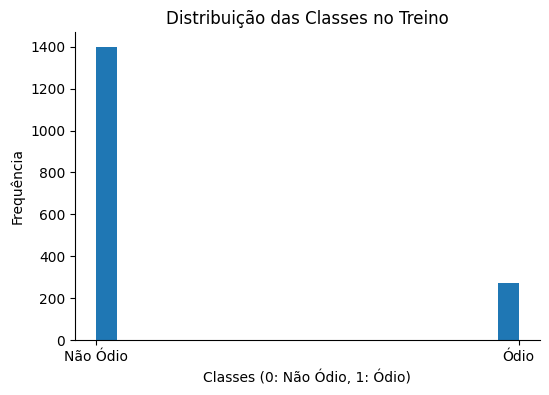

In [ ]:
# Mapear os rótulos numéricos para nomes significativos
class_labels = {0: 'Não Ódio', 1: 'Ódio'}

print("\n--- Contagem Exata das Classes (Treino) ---")
print(df_train['odio'].value_counts().rename(index=class_labels))

print("\n--- Distribuição de Ódio por Plataforma (Treino) ---")
print(df_train.groupby(['source', 'odio']).size().unstack(fill_value=0).rename(columns=class_labels))

print("\n--- Histograma da Distribuição das Classes (Treino) ---")
plt.figure(figsize=(6, 4))
df_train['odio'].plot(kind='hist', bins=20, title='Distribuição das Classes no Treino')
plt.xlabel('Classes (0: Não Ódio, 1: Ódio)')
plt.ylabel('Frequência')
plt.xticks([0, 1], ['Não Ódio', 'Ódio'])
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()


--- Distribuição de Ódio por Plataforma Treino ---


<Figure size 600x400 with 0 Axes>

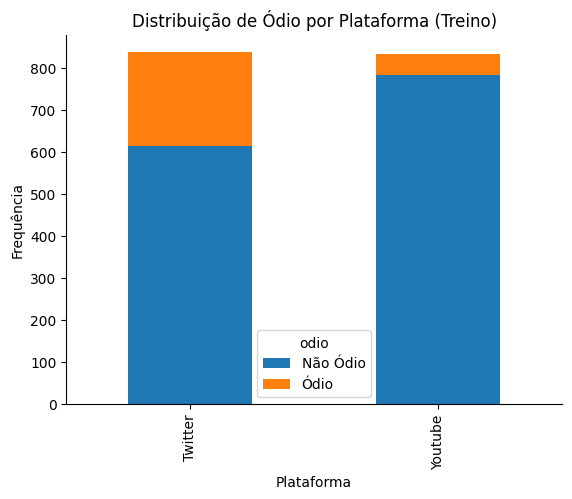

In [ ]:
print("\n--- Distribuição de Ódio por Plataforma Treino ---")
plt.figure(figsize=(6, 4))
df_train.groupby(['source', 'odio']).size().unstack(fill_value=0).rename(columns=class_labels).plot(kind='bar', stacked=True, title='Distribuição de Ódio por Plataforma (Treino)')
plt.xlabel('Plataforma')
plt.ylabel('Frequência')
plt.xticks(['source'].extend(list(class_labels.values())))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()


--- Contagem Exata das Classes (Teste) ---
odio
Não Ódio    352
Ódio         67
Name: count, dtype: int64

--- Distribuição de Ódio por Plataforma (Teste) ---
odio     Não Ódio  Ódio
source                 
Twitter       162    55
Youtube       190    12

--- Histograma da Distribuição das Classes (Teste) ---


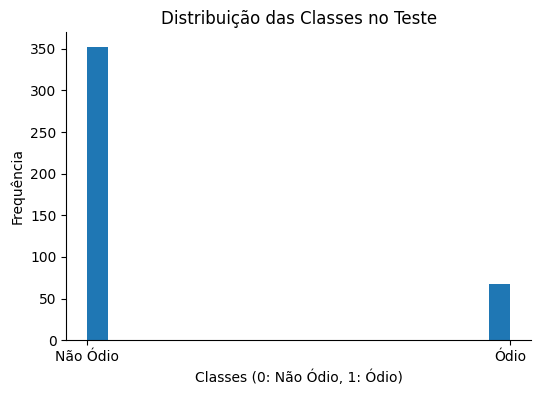

In [ ]:
print("\n--- Contagem Exata das Classes (Teste) ---")
print(df_test['odio'].value_counts().rename(index=class_labels))

print("\n--- Distribuição de Ódio por Plataforma (Teste) ---")
print(df_test.groupby(['source', 'odio']).size().unstack(fill_value=0).rename(columns=class_labels))

print("\n--- Histograma da Distribuição das Classes (Teste) ---")
plt.figure(figsize=(6, 4))
df_test['odio'].plot(kind='hist', bins=20, title='Distribuição das Classes no Teste')
plt.xlabel('Classes (0: Não Ódio, 1: Ódio)')
plt.ylabel('Frequência')
plt.xticks([0, 1], ['Não Ódio', 'Ódio'])
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()


--- Distribuição de Ódio por Plataforma Teste ---


<Figure size 600x400 with 0 Axes>

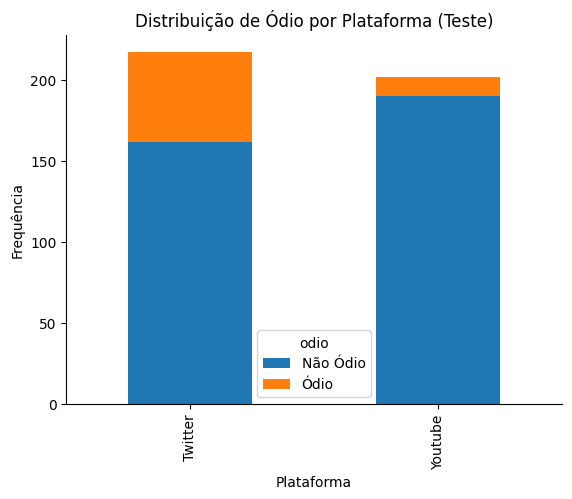

In [ ]:
print("\n--- Distribuição de Ódio por Plataforma Teste ---")
plt.figure(figsize=(6, 4))
df_test.groupby(['source', 'odio']).size().unstack(fill_value=0).rename(columns=class_labels).plot(kind='bar', stacked=True, title='Distribuição de Ódio por Plataforma (Teste)')
plt.xlabel('Plataforma')
plt.ylabel('Frequência')
plt.xticks(['source'].extend(list(class_labels.values())))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()


--- Visualizando a Distribuição do Comprimento dos Comentários por Classe ---


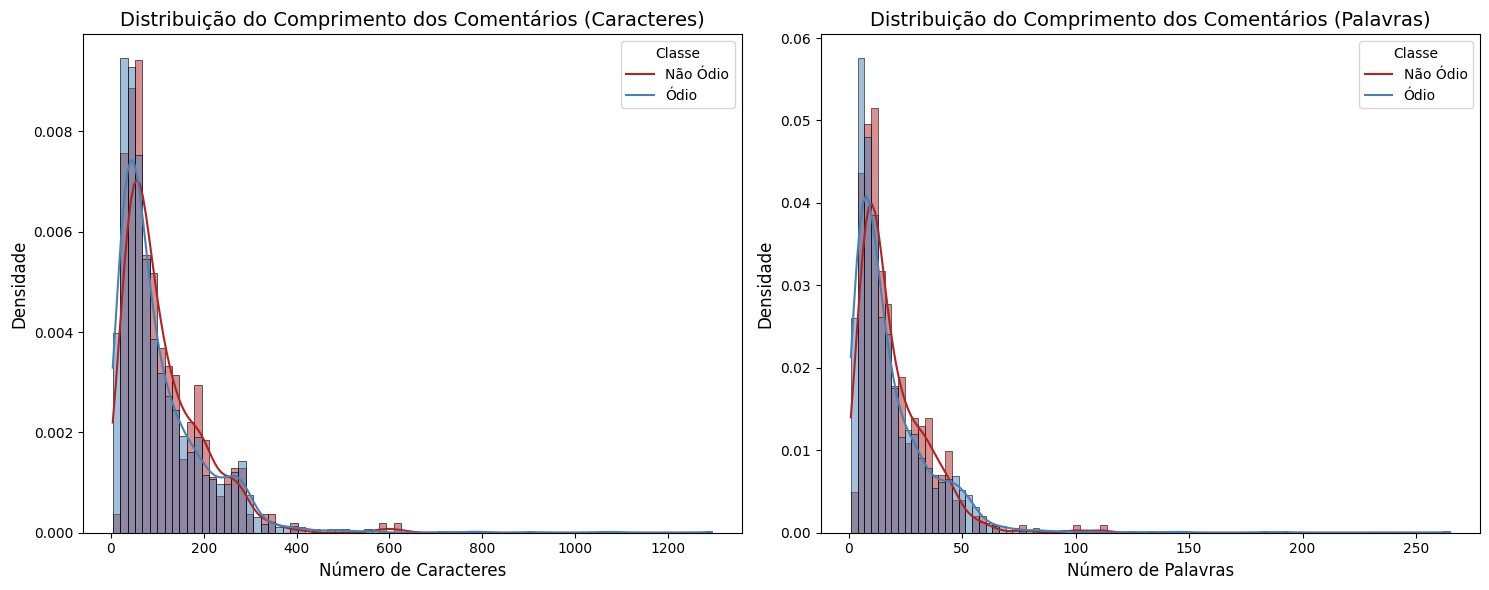


Gráficos de distribuição do comprimento dos comentários gerados.


In [ ]:
# --- Visualização do Comprimento dos Comentários por Classe (Treino e Teste Combinados) ---
print("\n--- Visualizando a Distribuição do Comprimento dos Comentários por Classe ---")

# Combinar os dataframes de treino e teste para análise de distribuição
df_combined = pd.concat([df_train.assign(split='treino'), df_test.assign(split='teste')])

# Calcular o comprimento do comentário em número de caracteres
df_combined['comment_length_char'] = df_combined['comment'].apply(len)

# Calcular o comprimento do comentário em número de palavras
df_combined['comment_length_word'] = df_combined['comment'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(15, 6))

# Gráfico de Distribuição do Comprimento por Caracteres
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(data=df_combined, x='comment_length_char', hue='odio', kde=True,
             palette={0: 'steelblue', 1: 'firebrick'}, stat="density", common_norm=False,
             hue_order=[0, 1]) # Garante ordem da legenda
plt.title('Distribuição do Comprimento dos Comentários (Caracteres)', fontsize=14)
plt.xlabel('Número de Caracteres', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(title='Classe', labels=[class_labels[0], class_labels[1]])


# Gráfico de Distribuição do Comprimento por Palavras
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(data=df_combined, x='comment_length_word', hue='odio', kde=True,
             palette={0: 'steelblue', 1: 'firebrick'}, stat="density", common_norm=False,
             hue_order=[0, 1]) # Garante ordem da legenda
plt.title('Distribuição do Comprimento dos Comentários (Palavras)', fontsize=14)
plt.xlabel('Número de Palavras', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(title='Classe', labels=[class_labels[0], class_labels[1]])

plt.tight_layout()
plt.show()

print("\nGráficos de distribuição do comprimento dos comentários gerados.")

**Análise**
Pico Principal (Comentários Curtos): Ambas as classes ("Não Ódio" e "Ódio") apresentam um pico de densidade muito acentuado para comentários com menos de 100 caracteres. Isso sugere que a maioria dos comentários, independentemente de serem de ódio ou não, tende a ser relativamente curta.

Pico Principal (Comentários Curtos): A maioria dos comentários (ambas as classes) tem menos de 25 palavras.

Distribuição da Classe "Não Ódio" (Cinza/Azul): Mais concentrada nos comentários muito curtos.

Distribuição da Classe "Ódio" (Vermelho): Mostra uma cauda ligeiramente mais longa para comentários com mais palavras (até 50-100 palavras), sugerindo que comentários de ódio podem ter, em média, um pouco mais de palavras do que comentários não-ódio, embora ainda predominantemente curtos.

4. Verificando o balanceamento das classes


--- Balanceamento das Classes em Tabela (Treino Original) ---
  Classe  Contagem Proporção
Não Ódio      1399     83.7%
    Ódio       273     16.3%


/tmp/ipython-input-51-4035346853.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts_train_original.index.map(class_labels), y=class_counts_train_original.values, palette='viridis')


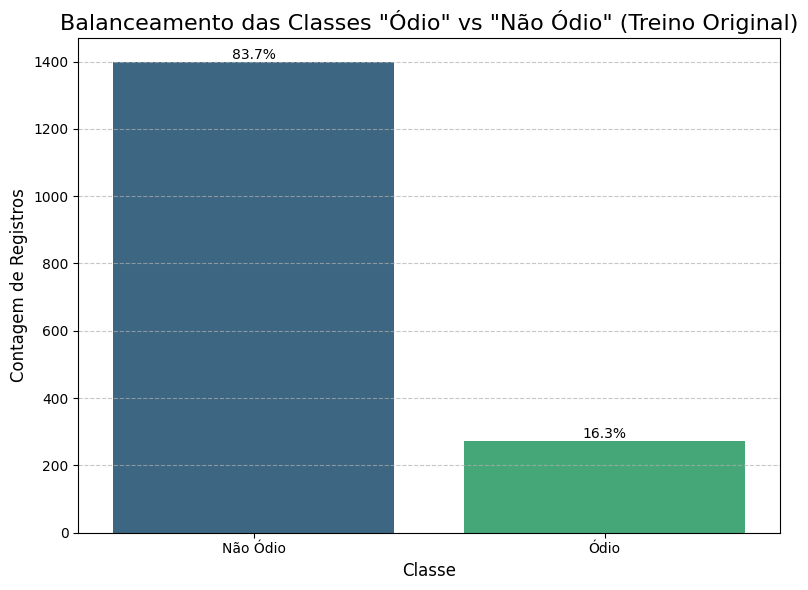


Gráfico de balanceamento de classes original gerado.


In [ ]:
# --- Calcular contagem e proporção das classes (Treino Original) ---
print("\n--- Balanceamento das Classes em Tabela (Treino Original) ---")
class_counts_train_original = df_train['odio'].value_counts()
class_proportions_train_original = df_train['odio'].value_counts(normalize=True)

balance_df_train = pd.DataFrame({
    'Classe': class_counts_train_original.index.map(class_labels),
    'Contagem': class_counts_train_original.values,
    'Proporção': [f'{p:.1%}' for p in class_proportions_train_original.values]
})
print(balance_df_train.to_string(index=False))

plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts_train_original.index.map(class_labels), y=class_counts_train_original.values, palette='viridis')
plt.title('Balanceamento das Classes "Ódio" vs "Não Ódio" (Treino Original)', fontsize=16)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Contagem de Registros', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, count in enumerate(class_counts_train_original.values):
    percentage = f'{class_proportions_train_original.values[i]:.1%}'
    plt.text(i, count + 0.5, percentage, ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
print("\nGráfico de balanceamento de classes original gerado.")

5. Verificação dos dados por classe

In [ ]:
# --- Baixar recursos NLTK (executar apenas na primeira vez) ---
# Tenta encontrar o recurso de stopwords. Se não encontrar (LookupError), então baixa.
try:
    nltk.data.find('corpora/stopwords')
except LookupError: # Catch the correct exception for resource not found
    print("Recurso 'stopwords' não encontrado. Baixando...")
    nltk.download('stopwords')
    print("'stopwords' baixado.")

# Tenta encontrar o recurso de tokenização 'punkt'. Se não encontrar (LookupError), então baixa.
try:
    nltk.data.find('tokenizers/punkt')
except LookupError: # Catch the correct exception for resource not found
    print("Recurso 'punkt' não encontrado. Baixando...")
    nltk.download('punkt')
    print("'punkt' baixado.")

In [ ]:
# Ensure 'punkt_tab' resource for portuguese is downloaded for word_tokenize to work correctly
try:
    nltk.data.find('tokenizers/punkt_tab/portuguese')
except LookupError:
    print("Recurso 'punkt_tab' para português não encontrado. Baixando...")
    nltk.download('punkt_tab') # Downloads the language-specific punkt tables
    print("'punkt_tab' baixado.")


Pré-processando comentários de Treino e Teste...
Pré-processamento concluído.

--- Comentários Limpos (Treino) ---
                                             comment  \
0  Sou mulher mãe de duas filhas mulheres e penso...   
1  Imagina se essa lei 4286/20 que vai entrar em ...   
2          a misoginia e uma fabrica de homossexuais   
3  @NOME Pobre FETO sabendo que MULHER é ABORTIST...   
4  Concordo Consta. Vejo pessoas indignadas mas q...   

                                       clean_comment  odio  
0        mulher mãe duas filhas mulheres penso igual     0  
1  imagina lei 428620 vai entrar votação passar c...     1  
2                     misoginia fabrica homossexuais     0  
3  pobre feto sabendo mulher abortista deve passa...     1  
4  concordo consta vejo pessoas indignadas apoiam...     0  

--- Comentários Limpos (Teste) ---
                                             comment  \
0  Te acho muito sensata nas tuas avaliações.Gran...   
1  Elizabeth Keen é uma filha da 

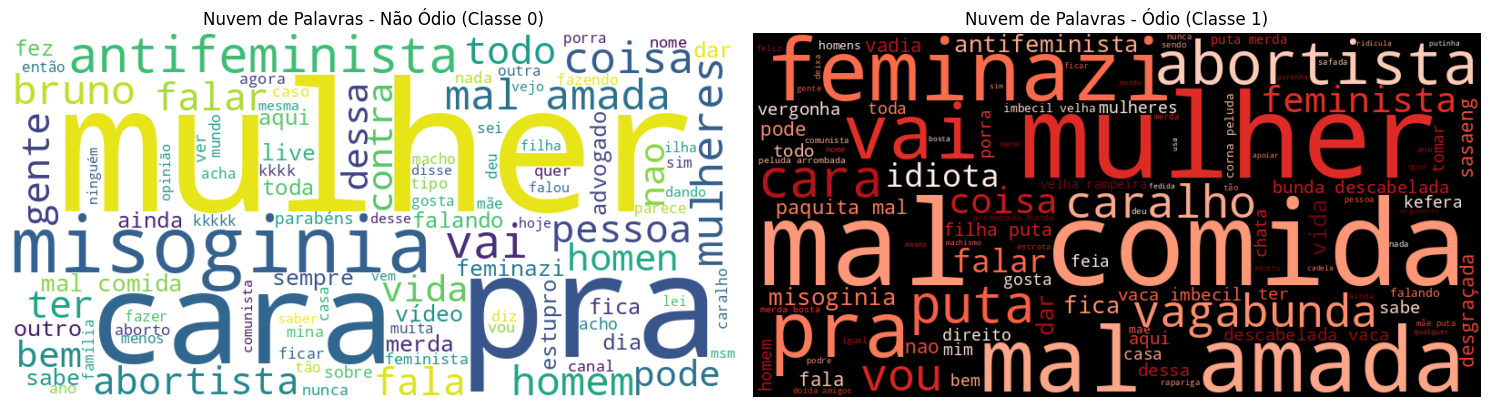


Nuvens de palavras geradas por classe.


In [ ]:
# --- Pré-processamento de Texto ---
# Função para limpar e tokenizar o texto
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'@\S+', '', text) # Remover menções
    text = re.sub(r'http\S+', '', text) # Remover URLs
    text = re.sub(r'#\S+', '', text) # Remover hashtags
    text = re.sub(r'_', '', text) # Remover underscores
    text = re.sub(r'[^\w\s]', '', text) # Remover pontuação e caracteres especiais
    tokens = word_tokenize(text, language='portuguese')
    filtered_tokens = [word for word in tokens if word not in stopwords_portuguese and len(word) > 2]
    return " ".join(filtered_tokens)

print("\nPré-processando comentários de Treino e Teste...")
df_train['clean_comment'] = df_train['comment'].apply(preprocess_text)
df_test['clean_comment'] = df_test['comment'].apply(preprocess_text)
print("Pré-processamento concluído.")
print("\n--- Comentários Limpos (Treino) ---")
print(df_train[['comment', 'clean_comment', 'odio']].head())
print("\n--- Comentários Limpos (Teste) ---")
print(df_test[['comment', 'clean_comment', 'odio']].head())


# --- Separar os comentários por classe (para WordCloud) ---
comments_no_odio = " ".join(df_train[df_train['odio'] == 0]['clean_comment'].tolist())
comments_odio = " ".join(df_train[df_train['odio'] == 1]['clean_comment'].tolist())

# Verificar se há comentários em cada classe para evitar erros
if not comments_no_odio.strip():
    print("Aviso: Nenhuns comentários encontrados para a classe 'Não Ódio' após pré-processamento.")
if not comments_odio.strip():
    print("Aviso: Nenhuns comentários encontrados para a classe 'Ódio' após pré-processamento.")


# --- Gerar e Exibir Nuvens de Palavras ---
plt.figure(figsize=(15, 7))

# Nuvem de Palavras para "Não Ódio"
if comments_no_odio.strip():
    wordcloud_no_odio = WordCloud(width=800, height=400, background_color='white',
                                  max_words=100, contour_width=3, contour_color='steelblue').generate(comments_no_odio)
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(wordcloud_no_odio, interpolation='bilinear')
    ax1.axis('off')
    ax1.set_title('Nuvem de Palavras - Não Ódio (Classe 0)')
else:
    ax1 = plt.subplot(1, 2, 1)
    ax1.text(0.5, 0.5, 'Dados insuficientes para Nuvem de Palavras', ha='center', va='center', fontsize=12)
    ax1.axis('off')
    ax1.set_title('Nuvem de Palavras - Não Ódio (Classe 0)')

# Nuvem de Palavras para "Ódio"
if comments_odio.strip():
    wordcloud_odio = WordCloud(width=800, height=400, background_color='black', colormap='Reds',
                               max_words=100, contour_width=3, contour_color='firebrick').generate(comments_odio)
    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(wordcloud_odio, interpolation='bilinear')
    ax2.axis('off')
    ax2.set_title('Nuvem de Palavras - Ódio (Classe 1)')
else:
    ax2 = plt.subplot(1, 2, 2)
    ax2.text(0.5, 0.5, 'Dados insuficientes para Nuvem de Palavras', ha='center', va='center', fontsize=12, color='white')
    ax2.set_facecolor('black')
    ax2.axis('off')
    ax2.set_title('Nuvem de Palavras - Ódio (Classe 1)', color='white')

plt.tight_layout()
plt.show()
print("\nNuvens de palavras geradas por classe.")





Conclusão: Eu gerei a nuvem de palavras no dataset original, com as classes ainda desbalanceadas.
Na sequência, foi realizado um pré-processamento, com a limpeza, tokenização e aplicação de stopwords.

6. Balanceamento de Classes com Oversampling (SMOTE) e Vetorização TF-IDF


Vetorizando textos de treino e teste com TF-IDF...
Shape vetorizado de treino: (1672, 5000)
Shape vetorizado de teste: (419, 5000)

--- Aplicando SMOTE no conjunto de TREINO ---
Shape do treino após SMOTE: (2798, 5000)
Contagem de classes no treino após SMOTE: Counter({0: 1399, 1: 1399})

Balanceamento das Classes em Tabela (Treino Após SMOTE):
  Classe  Contagem Proporção
Não Ódio      1399     50.0%
    Ódio      1399     50.0%


/tmp/ipython-input-55-1146110867.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts_smote_train.index.map(class_labels), y=class_counts_smote_train.values, palette='viridis')


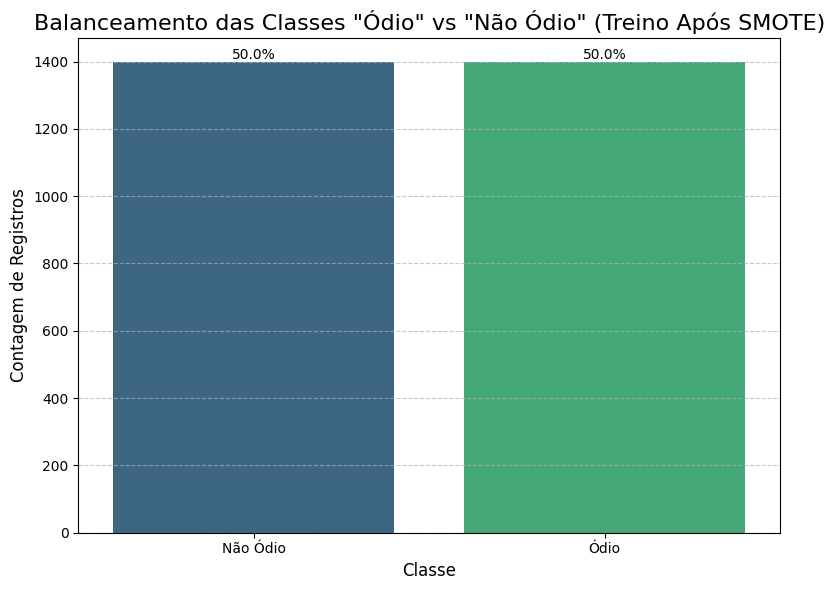


Gráfico de balanceamento de classes no treino após SMOTE gerado.


In [ ]:
# Definir X e y para o treino
X_train = df_train['clean_comment']
y_train = df_train['odio']

# Definir X_test e y_test para o teste
X_test = df_test['clean_comment']
y_test = df_test['odio']

# 1. Vetorizar os textos de TREINO e TESTE separadamente
print("\nVetorizando textos de treino e teste com TF-IDF...")
tfidf_vectorizer_model = TfidfVectorizer(max_features=5000, stop_words=list(stopwords_portuguese), min_df=1)
X_train_vectorized = tfidf_vectorizer_model.fit_transform(X_train)
X_test_vectorized = tfidf_vectorizer_model.transform(X_test)

print(f"Shape vetorizado de treino: {X_train_vectorized.shape}")
print(f"Shape vetorizado de teste: {X_test_vectorized.shape}")


# 2. Aplicar SMOTE APENAS no conjunto de TREINO VETORIZADO
print("\n--- Aplicando SMOTE no conjunto de TREINO ---")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vectorized, y_train)

print(f"Shape do treino após SMOTE: {X_train_resampled.shape}")
print(f"Contagem de classes no treino após SMOTE: {Counter(y_train_resampled)}")

# Visualizar o balanceamento das classes após SMOTE no TREINO
class_counts_smote_train = pd.Series(y_train_resampled).value_counts()
class_proportions_smote_train = pd.Series(y_train_resampled).value_counts(normalize=True)

balance_smote_train_df = pd.DataFrame({
    'Classe': class_counts_smote_train.index.map(class_labels),
    'Contagem': class_counts_smote_train.values,
    'Proporção': [f'{p:.1%}' for p in class_proportions_smote_train.values]
})
print("\nBalanceamento das Classes em Tabela (Treino Após SMOTE):")
print(balance_smote_train_df.to_string(index=False))

plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts_smote_train.index.map(class_labels), y=class_counts_smote_train.values, palette='viridis')
plt.title('Balanceamento das Classes "Ódio" vs "Não Ódio" (Treino Após SMOTE)', fontsize=16)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Contagem de Registros', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, count in enumerate(class_counts_smote_train.values):
    percentage = f'{class_proportions_smote_train.values[i]:.1%}'
    plt.text(i, count + 0.5, percentage, ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
print("\nGráfico de balanceamento de classes no treino após SMOTE gerado.")

7. Aplicação do Modelo Multinomial Naive Bayes - "MultinomialNB


--- Treinando o modelo Multinomial Naive Bayes nos dados de treino balanceados ---
Treinamento concluído.

--- Avaliação no Conjunto de TREINO (BALANCEADO - Multinomial Naive Bayes) ---
Acurácia (Treino Balanceado): 0.9525

Relatório de Classificação (Treino Balanceado):
              precision    recall  f1-score   support

    Não Ódio       1.00      0.91      0.95      1399
        Ódio       0.92      1.00      0.95      1399

    accuracy                           0.95      2798
   macro avg       0.96      0.95      0.95      2798
weighted avg       0.96      0.95      0.95      2798


--- Avaliação no Conjunto de TESTE (Multinomial Naive Bayes) ---
Acurácia (Teste): 0.7422

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

    Não Ódio       0.92      0.76      0.83       352
        Ódio       0.34      0.67      0.45        67

    accuracy                           0.74       419
   macro avg       0.63      0.71      0.64       419


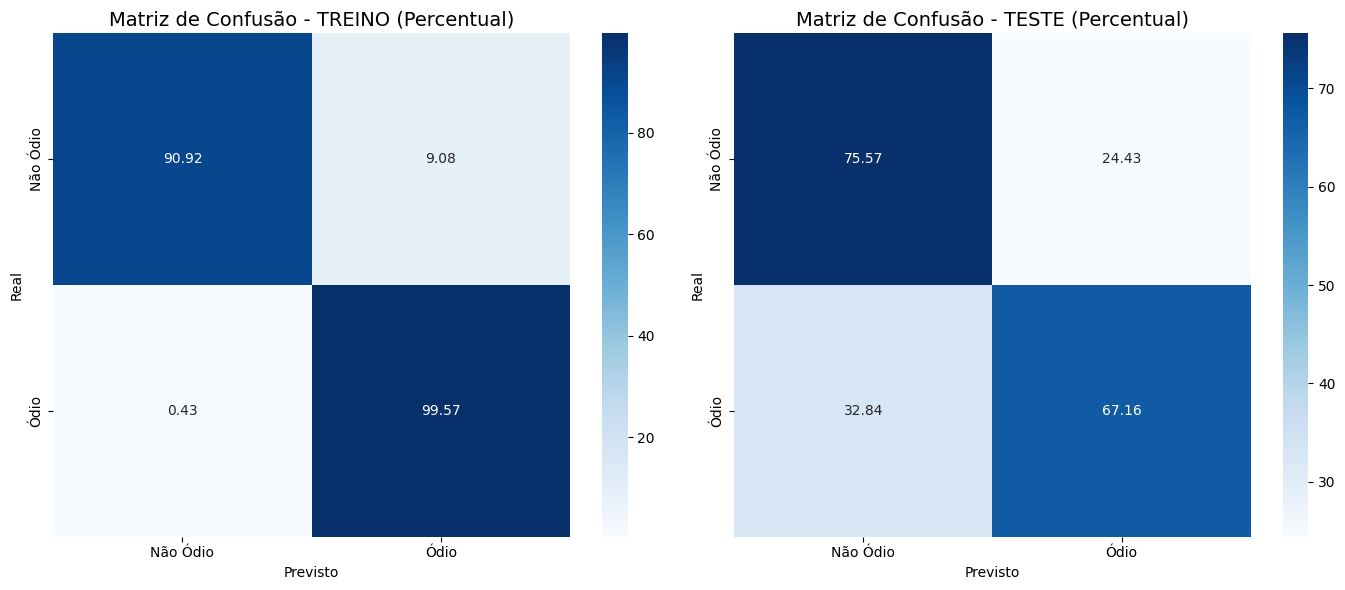


Análise do modelo Multinomial Naive Bayes com dados balanceados concluída.


In [ ]:
# 3. Treinar o modelo Multinomial Naive Bayes nos dados balanceados
print("\n--- Treinando o modelo Multinomial Naive Bayes nos dados de treino balanceados ---")
model_nb_balanced = MultinomialNB()
model_nb_balanced.fit(X_train_resampled, y_train_resampled)
print("Treinamento concluído.")

# 4. Avaliar o Modelo Lado a Lado (Treino e Teste)
# Previsões para o conjunto de TREINO (BALANCEADO)
y_train_pred_nb_balanced = model_nb_balanced.predict(X_train_resampled)
print("\n--- Avaliação no Conjunto de TREINO (BALANCEADO - Multinomial Naive Bayes) ---")
accuracy_train_nb_balanced = accuracy_score(y_train_resampled, y_train_pred_nb_balanced)
print(f"Acurácia (Treino Balanceado): {accuracy_train_nb_balanced:.4f}")
print("\nRelatório de Classificação (Treino Balanceado):")
print(classification_report(y_train_resampled, y_train_pred_nb_balanced, target_names=list(class_labels.values()), zero_division='warn'))

# Previsões para o conjunto de TESTE (VETORIZADO)
y_test_pred_nb_balanced = model_nb_balanced.predict(X_test_vectorized)
print("\n--- Avaliação no Conjunto de TESTE (Multinomial Naive Bayes) ---")
accuracy_test_nb_balanced = accuracy_score(y_test, y_test_pred_nb_balanced)
print(f"Acurácia (Teste): {accuracy_test_nb_balanced:.4f}")
print("\nRelatório de Classificação (Teste):")
print(classification_report(y_test, y_test_pred_nb_balanced, target_names=list(class_labels.values()), zero_division='warn'))


# --- 5. Visualizar Matrizes de Confusão Lado a Lado (Multinomial Naive Bayes) ---
print("\nGerando Matrizes de Confusão Lado a Lado (Multinomial Naive Bayes)...")

# Matriz de Confusão para TREINO (BALANCEADO)
cm_train_nb_balanced = confusion_matrix(y_train_resampled, y_train_pred_nb_balanced)

cm_train_nb_balanced_percent = cm_train_nb_balanced.astype('float') / cm_train_nb_balanced.sum(axis=1)[:, np.newaxis]

# 2. Arredondar os valores para melhor visualização (opcional)
cm_train_nb_balanced_percent = np.round(cm_train_nb_balanced_percent * 100, 2) # Multiplica por 100 para ter percentual e arredonda

# cm_train_nb_balanced = confusion_matrix(y_train_resampled, y_train_pred_nb_balanced)
# cm_test_nb_balanced = confusion_matrix(y_test, y_test_pred_nb_balanced)

# --- Converter as matrizes de confusão para percentual ---

# Matriz de Confusão para TREINO
cm_train_nb_balanced_percent = cm_train_nb_balanced.astype('float') / cm_train_nb_balanced.sum(axis=1)[:, np.newaxis]
cm_train_nb_balanced_percent = np.round(cm_train_nb_balanced_percent * 100, 2)

# Matriz de Confusão para TESTE
cm_test_nb_balanced_percent = cm_test_nb_balanced.astype('float') / cm_test_nb_balanced.sum(axis=1)[:, np.newaxis]
cm_test_nb_balanced_percent = np.round(cm_test_nb_balanced_percent * 100, 2)

# --- Plotar as matrizes de confusão lado a lado ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 1 linha, 2 colunas para os plots

# Plot da Matriz de Confusão de TREINO
sns.heatmap(cm_train_nb_balanced_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True,
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[0])
axes[0].set_title('Matriz de Confusão - TREINO (Percentual)', fontsize=14)
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# Plot da Matriz de Confusão de TESTE
sns.heatmap(cm_test_nb_balanced_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True,
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[1])
axes[1].set_title('Matriz de Confusão - TESTE (Percentual)', fontsize=14)
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.tight_layout() # Ajusta automaticamente os parâmetros do subplot para que fiquem bem ajustados
plt.show()

print("\nAnálise do modelo Multinomial Naive Bayes com dados balanceados concluída.")

8. Treinar o modelo Random Forest nos dados balanceados (Sem Otimização)


--- Treinando o modelo Random Forest nos dados de treino balanceados (Padrão) ---
Treinamento concluído.

--- Relatório de Classificação (Treino Balanceado - Random Forest Padrão) ---
              precision    recall  f1-score   support

    Não Ódio       1.00      1.00      1.00      1399
        Ódio       1.00      1.00      1.00      1399

    accuracy                           1.00      2798
   macro avg       1.00      1.00      1.00      2798
weighted avg       1.00      1.00      1.00      2798


--- Relatório de Classificação (Teste - Random Forest Padrão) ---
              precision    recall  f1-score   support

    Não Ódio       0.90      0.91      0.91       352
        Ódio       0.51      0.48      0.49        67

    accuracy                           0.84       419
   macro avg       0.70      0.69      0.70       419
weighted avg       0.84      0.84      0.84       419


Gerando Matrizes de Confusão Lado a Lado (Random Forest Padrão - Percentual)...


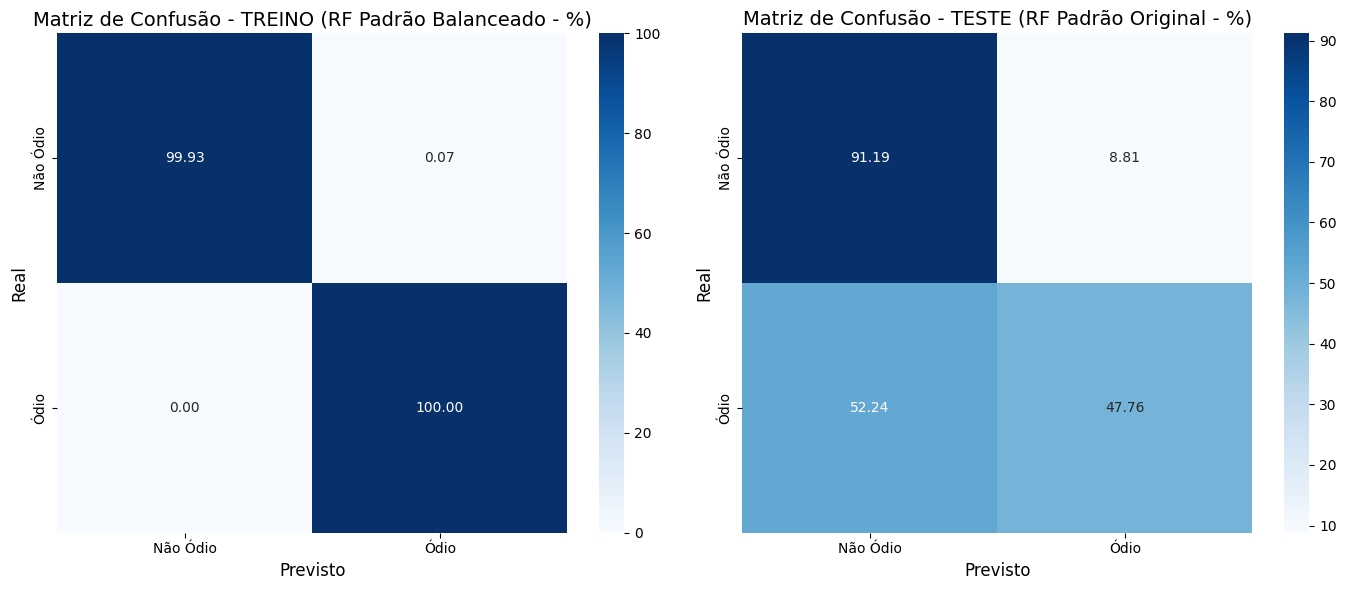


Análise do modelo Random Forest


In [ ]:
# 3. Treinar o modelo Random Forest nos dados balanceados (sem otimização explícita de hiperparâmetros neste passo)
print("\n--- Treinando o modelo Random Forest nos dados de treino balanceados (Padrão) ---")
model_rf_balanced_default = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model_rf_balanced_default.fit(X_train_resampled, y_train_resampled)
print("Treinamento concluído.")

# Fazer previsões para avaliação
y_train_pred_rf_balanced_default = model_rf_balanced_default.predict(X_train_resampled)
y_test_pred_rf_balanced_default = model_rf_balanced_default.predict(X_test_vectorized)


print("\n--- Relatório de Classificação (Treino Balanceado - Random Forest Padrão) ---")
print(classification_report(y_train_resampled, y_train_pred_rf_balanced_default, target_names=list(class_labels.values())))

print("\n--- Relatório de Classificação (Teste - Random Forest Padrão) ---")
print(classification_report(y_test, y_test_pred_rf_balanced_default, target_names=list(class_labels.values())))


# --- Matriz de Confusão para TREINO (BALANCEADO) ---
cm_train_rf_balanced_default = confusion_matrix(y_train_resampled, y_train_pred_rf_balanced_default)

# Converter para percentual
cm_train_rf_balanced_default_percent = cm_train_rf_balanced_default.astype('float') / cm_train_rf_balanced_default.sum(axis=1)[:, np.newaxis]
cm_train_rf_balanced_default_percent = np.round(cm_train_rf_balanced_default_percent * 100, 2) # Multiplica por 100 e arredonda

# --- Matriz de Confusão para TESTE (usando modelo balanceado) ---
cm_test_rf_balanced_default = confusion_matrix(y_test, y_test_pred_rf_balanced_default)

# Converter para percentual
cm_test_rf_balanced_default_percent = cm_test_rf_balanced_default.astype('float') / cm_test_rf_balanced_default.sum(axis=1)[:, np.newaxis]
cm_test_rf_balanced_default_percent = np.round(cm_test_rf_balanced_default_percent * 100, 2) # Multiplica por 100 e arredonda

# --- Visualizar Matrizes de Confusão Lado a Lado (Random Forest Padrão - Percentual) ---
print("\nGerando Matrizes de Confusão Lado a Lado (Random Forest Padrão - Percentual)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Ajustei figsize para melhor legibilidade dos percentuais

# Plot da Matriz de Confusão de TREINO (Percentual)
sns.heatmap(cm_train_rf_balanced_default_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # cbar=True para mostrar a barra de cores
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[0])
axes[0].set_title('Matriz de Confusão - TREINO (RF Padrão Balanceado - %)', fontsize=14)
axes[0].set_xlabel('Previsto', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Plot da Matriz de Confusão de TESTE (Percentual)
sns.heatmap(cm_test_rf_balanced_default_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # cbar=True para mostrar a barra de cores
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[1])
axes[1].set_title('Matriz de Confusão - TESTE (RF Padrão Original - %)', fontsize=14)
axes[1].set_xlabel('Previsto', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

print("\nAnálise do modelo Random Forest")

O modelo Random Forest padrão demonstra um desempenho perfeito no conjunto de treino balanceado. Alcançar 100% em todas as métricas (precisão, recall, F1-score e acurácia) para ambas as classes sugere overfitting (sobreajuste). Isso significa que o modelo aprendeu os dados de treino de forma muito específica, incluindo o ruído, e pode ter dificuldade em generalizar para dados novos e não vistos (o conjunto de teste).

É crucial comparar este desempenho com os resultados no conjunto de teste para ter uma avaliação realista da capacidade de generalização do modelo. Se o desempenho no teste for significativamente menor, o overfitting é confirmado.

9. Usando GridSearchCV (Otimização para Random Forest)


--- 4. Otimização de Hiperparâmetros (GridSearchCV) para Random Forest ---

Exemplo de 'param_grid' para GridSearchCV do RandomForestClassifier:
  'n_estimators': [50, 100]
  'max_features': ['sqrt']
  'max_depth': [10, 20]
  'min_samples_split': [2, 5]
  'min_samples_leaf': [1, 2]
  'bootstrap': [True]
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Melhores parâmetros (GridSearchCV): {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Melhor pontuação F1 (GridSearchCV): 0.8640

Modelo Random Forest otimizado por GridSearchCV treinado com os melhores parâmetros.

--- Relatório de Classificação (Treino Balanceado - RF GridSearchCV Otimizado) ---
              precision    recall  f1-score   support

    Não Ódio       0.87      0.98      0.92      1399
        Ódio       0.98      0.85      0.91      1399

    accuracy                           0.91      2798
   macro avg       0.92      0.91   

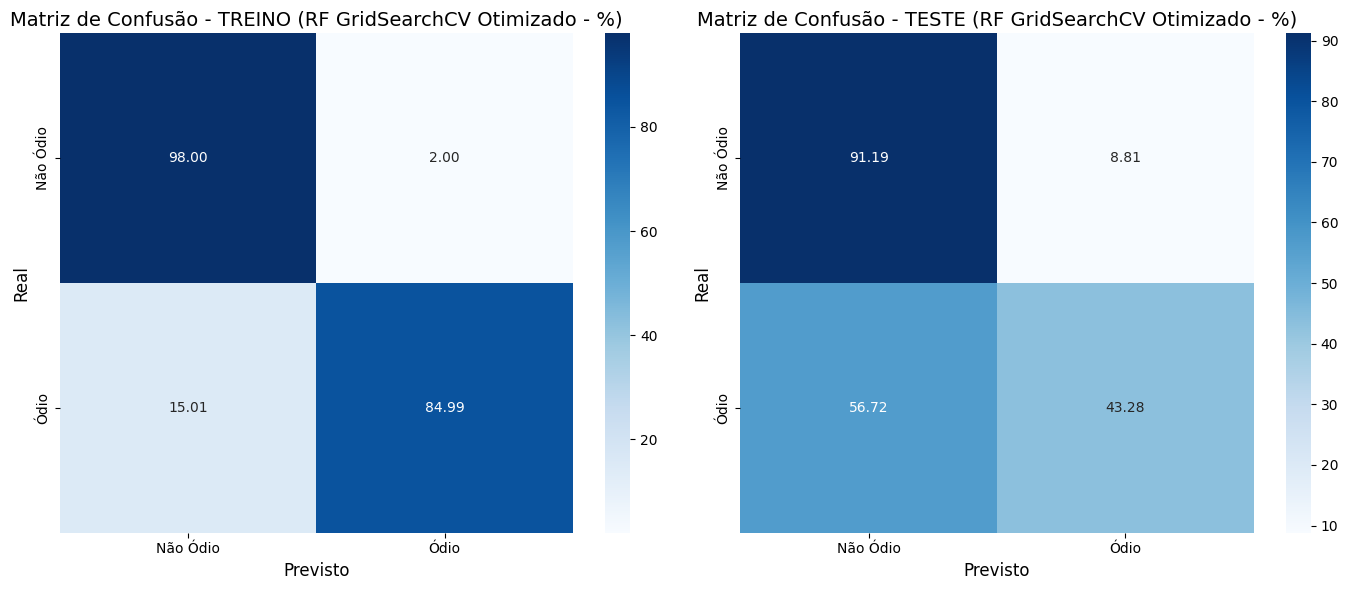


Análise do modelo Random Forest otimizado por GridSearchCV concluída.


In [ ]:
print("\n--- 4. Otimização de Hiperparâmetros (GridSearchCV) para Random Forest ---")

# Definir o modelo base para a busca
rf_estimator_grid = RandomForestClassifier(random_state=42, class_weight='balanced')

# Para GridSearchCV (Pesquisa em Grade Exaustiva)
param_grid_rf = {
    'n_estimators': [50, 100],  # Reduzido para exemplo rápido
    'max_features': ['sqrt'], # Reduzido para exemplo rápido
    'max_depth': [10, 20], # Reduzido para exemplo rápido
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}
print("\nExemplo de 'param_grid' para GridSearchCV do RandomForestClassifier:")
for key, value in param_grid_rf.items():
    print(f"  '{key}': {value}")

grid_search_rf = GridSearchCV(estimator=rf_estimator_grid,
                              param_grid=param_grid_rf, cv=3, n_jobs=-1, verbose=1, scoring='f1_macro')
grid_search_rf.fit(X_train_resampled, y_train_resampled)

print(f"\nMelhores parâmetros (GridSearchCV): {grid_search_rf.best_params_}")
print(f"Melhor pontuação F1 (GridSearchCV): {grid_search_rf.best_score_:.4f}")

# Treinar o modelo Random Forest FINAL com os melhores parâmetros encontrados pelo GridSearchCV
model_rf_grid_optimized = grid_search_rf.best_estimator_
print("\nModelo Random Forest otimizado por GridSearchCV treinado com os melhores parâmetros.")

# Fazer previsões para avaliação
y_train_pred_rf_grid_optimized = model_rf_grid_optimized.predict(X_train_resampled)
y_test_pred_rf_grid_optimized = model_rf_grid_optimized.predict(X_test_vectorized)


print("\n--- Relatório de Classificação (Treino Balanceado - RF GridSearchCV Otimizado) ---")
print(classification_report(y_train_resampled, y_train_pred_rf_grid_optimized, target_names=list(class_labels.values())))

print("\n--- Relatório de Classificação (Teste - RF GridSearchCV Otimizado) ---")
print(classification_report(y_test, y_test_pred_rf_grid_optimized, target_names=list(class_labels.values())))


# --- Visualizar Matrizes de Confusão Lado a Lado (Random Forest GridSearchCV Otimizado - Percentual) ---
print("\nGerando Matrizes de Confusão Lado a Lado (Random Forest GridSearchCV Otimizado - Percentual)...")

# Matriz de Confusão para TREINO (BALANCEADO)
cm_train_rf_grid_optimized = confusion_matrix(y_train_resampled, y_train_pred_rf_grid_optimized)

# Convert to percentage
cm_train_rf_grid_optimized_percent = cm_train_rf_grid_optimized.astype('float') / cm_train_rf_grid_optimized.sum(axis=1)[:, np.newaxis]
cm_train_rf_grid_optimized_percent = np.round(cm_train_rf_grid_optimized_percent * 100, 2) # Multiply by 100 for percentage and round

# Matriz de Confusão para TESTE (usando modelo balanceado)
cm_test_rf_grid_optimized = confusion_matrix(y_test, y_test_pred_rf_grid_optimized)

# Convert to percentage
cm_test_rf_grid_optimized_percent = cm_test_rf_grid_optimized.astype('float') / cm_test_rf_grid_optimized.sum(axis=1)[:, np.newaxis]
cm_test_rf_grid_optimized_percent = np.round(cm_test_rf_grid_optimized_percent * 100, 2) # Multiply by 100 for percentage and round


fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Ajustei figsize para melhor legibilidade dos percentuais

# Plot da Matriz de Confusão de TREINO (Percentual)
sns.heatmap(cm_train_rf_grid_optimized_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # cbar=True para mostrar a barra de cores
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[0])
axes[0].set_title('Matriz de Confusão - TREINO (RF GridSearchCV Otimizado - %)', fontsize=14)
axes[0].set_xlabel('Previsto', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Plot da Matriz de Confusão de TESTE (Percentual)
sns.heatmap(cm_test_rf_grid_optimized_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # cbar=True para mostrar a barra de cores
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[1])
axes[1].set_title('Matriz de Confusão - TESTE (RF GridSearchCV Otimizado - %)', fontsize=14)
axes[1].set_xlabel('Previsto', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

print("\nAnálise do modelo Random Forest otimizado por GridSearchCV concluída.")

10. Usando RandomizedSearchCV (Otimização para Random Forest)


--- 4. Otimização de Hiperparâmetros (RandomizedSearchCV) e Treinamento do Modelo Random Forest ---

Exemplo de 'param_distributions' para RandomizedSearchCV do RandomForestClassifier:
  'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ebd67ea50d0>
  'max_features': ['sqrt', 'log2']
  'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ebdc25431d0>
  'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ebdcce162d0>
  'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ebdcce15150>
  'bootstrap': [True, False]
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Melhores parâmetros encontrados por RandomizedSearchCV: {'bootstrap': True, 'max_depth': 38, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 238}
Melhor pontuação F1 (macro) de validação cruzada: 0.8948

Modelo Random Forest final otimizado por Random

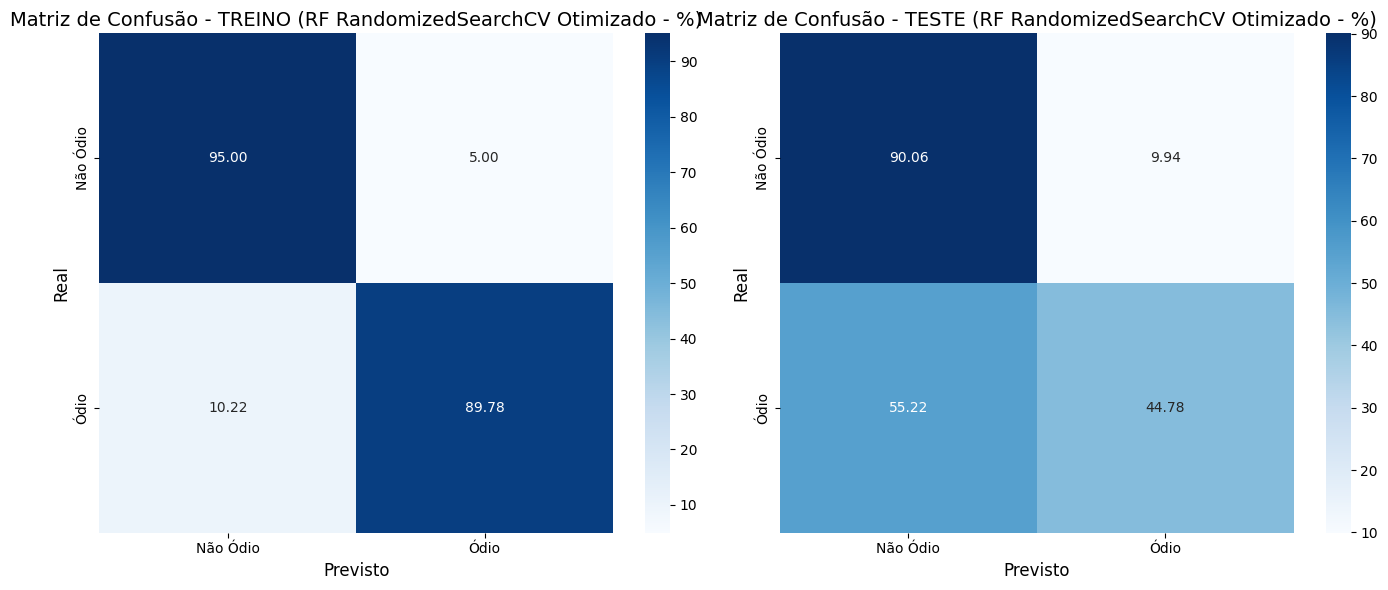


Análise do modelo Random Forest otimizado por RandomizedSearchCV concluída.


In [ ]:
print("\n--- 4. Otimização de Hiperparâmetros (RandomizedSearchCV) e Treinamento do Modelo Random Forest ---")

# Definir o modelo base para a busca
rf_estimator_random = RandomForestClassifier(random_state=42, class_weight='balanced')

# Para RandomizedSearchCV (Pesquisa Aleatória)
param_distributions_rf = {
    'n_estimators': randint(50, 250),
    'max_features': ['sqrt', 'log2'],
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False]
}
print("\nExemplo de 'param_distributions' para RandomizedSearchCV do RandomForestClassifier:")
for key, value in param_distributions_rf.items():
    print(f"  '{key}': {value}")

random_search_rf = RandomizedSearchCV(estimator=rf_estimator_random,
                                      param_distributions=param_distributions_rf,
                                      n_iter=10, # Número de iterações, aumente para uma busca mais exaustiva
                                      cv=3,
                                      n_jobs=-1,
                                      verbose=1,
                                      random_state=42,
                                      scoring='f1_macro')
random_search_rf.fit(X_train_resampled, y_train_resampled)

print(f"\nMelhores parâmetros encontrados por RandomizedSearchCV: {random_search_rf.best_params_}")
print(f"Melhor pontuação F1 (macro) de validação cruzada: {random_search_rf.best_score_:.4f}")

# Treinar o modelo Random Forest FINAL com os melhores parâmetros encontrados
model_rf_random_optimized = random_search_rf.best_estimator_
print("\nModelo Random Forest final otimizado por RandomizedSearchCV treinado com os melhores parâmetros.")

# Fazer previsões para avaliação
y_train_pred_rf_random_optimized = model_rf_random_optimized.predict(X_train_resampled)
y_test_pred_rf_random_optimized = model_rf_random_optimized.predict(X_test_vectorized)


print("\n--- Relatório de Classificação (Treino Balanceado - RF RandomizedSearchCV Otimizado) ---")
print(classification_report(y_train_resampled, y_train_pred_rf_random_optimized, target_names=list(class_labels.values())))

print("\n--- Relatório de Classificação (Teste - RF RandomizedSearchCV Otimizado) ---")
print(classification_report(y_test, y_test_pred_rf_random_optimized, target_names=list(class_labels.values())))


# --- Matriz de Confusão para TREINO (BALANCEADO) ---
cm_train_rf_random_optimized = confusion_matrix(y_train_resampled, y_train_pred_rf_random_optimized)

# Converter para percentual
cm_train_rf_random_optimized_percent = cm_train_rf_random_optimized.astype('float') / cm_train_rf_random_optimized.sum(axis=1)[:, np.newaxis]
cm_train_rf_random_optimized_percent = np.round(cm_train_rf_random_optimized_percent * 100, 2) # Multiplica por 100 e arredonda

# --- Matriz de Confusão para TESTE (usando modelo balanceado) ---
cm_test_rf_random_optimized = confusion_matrix(y_test, y_test_pred_rf_random_optimized)

# Converter para percentual
cm_test_rf_random_optimized_percent = cm_test_rf_random_optimized.astype('float') / cm_test_rf_random_optimized.sum(axis=1)[:, np.newaxis]
cm_test_rf_random_optimized_percent = np.round(cm_test_rf_random_optimized_percent * 100, 2) # Multiplica por 100 e arredonda

# --- Visualizar Matrizes de Confusão Lado a Lado (Random Forest RandomizedSearchCV Otimizado - Percentual) ---
print("\nGerando Matrizes de Confusão Lado a Lado (Random Forest RandomizedSearchCV Otimizado - Percentual)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Ajustei figsize para melhor legibilidade dos percentuais

# Plot da Matriz de Confusão de TREINO (Percentual)
sns.heatmap(cm_train_rf_random_optimized_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # cbar=True para mostrar a barra de cores
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[0])
axes[0].set_title('Matriz de Confusão - TREINO (RF RandomizedSearchCV Otimizado - %)', fontsize=14)
axes[0].set_xlabel('Previsto', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Plot da Matriz de Confusão de TESTE (Percentual)
sns.heatmap(cm_test_rf_random_optimized_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # cbar=True para mostrar a barra de cores
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[1])
axes[1].set_title('Matriz de Confusão - TESTE (RF RandomizedSearchCV Otimizado - %)', fontsize=14)
axes[1].set_xlabel('Previsto', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

print("\nAnálise do modelo Random Forest otimizado por RandomizedSearchCV concluída.")

11. Usando Gradient Boosting FINAL


--- Otimização de Hiperparâmetros (RandomizedSearchCV) e Treinamento do Modelo Gradient Boosting ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Melhores parâmetros encontrados por RandomizedSearchCV para GB: {'learning_rate': np.float64(0.1323306320976562), 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 98, 'subsample': np.float64(0.8099098641033556)}
Melhor pontuação F1 (macro) de validação cruzada para GB: 0.9164

Modelo Gradient Boosting final otimizado treinado com os melhores parâmetros.

--- Avaliação do Modelo Gradient Boosting Otimizado no Conjunto de TESTE (Original) ---
Acurácia (Teste - Modelo Gradient Boosting Otimizado): 0.8568

Relatório de Classificação (Teste - Modelo Gradient Boosting Otimizado):
              precision    recall  f1-score   support

    Não Ódio       0.91      0.92      0.92       352
        Ódio       0.55      0.54      0.55        67

    accuracy                           0.86       419
   macro avg       0.73      0

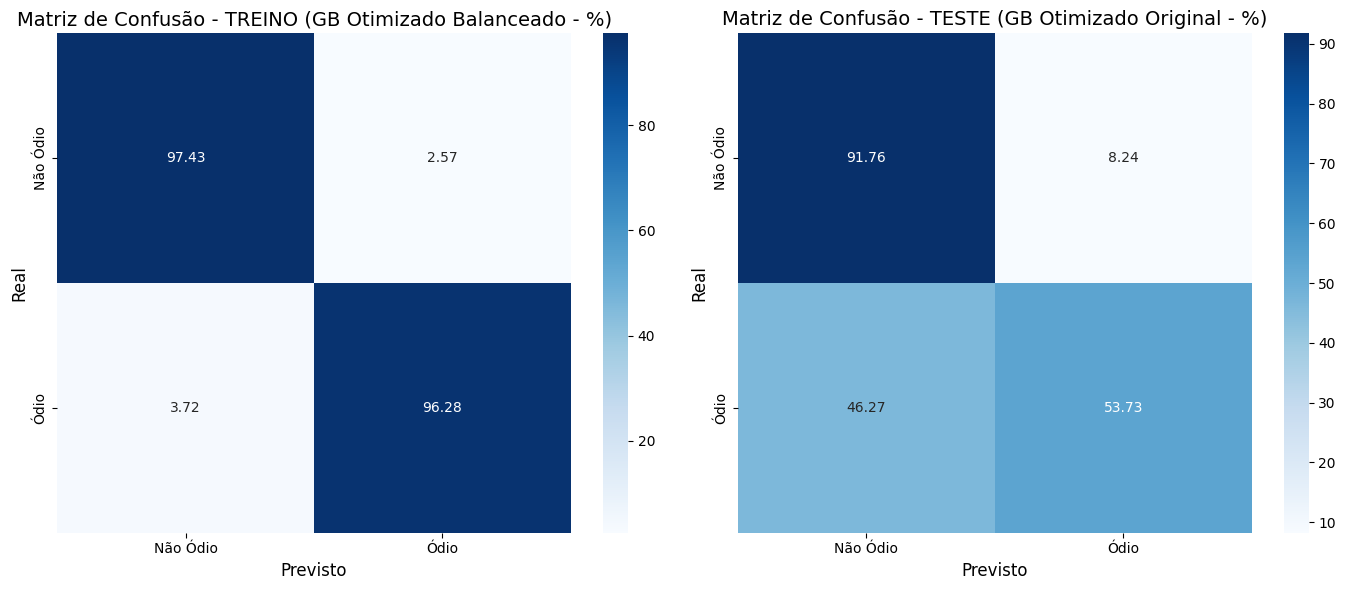


Análise do modelo Gradient Boosting otimizado com dados balanceados concluída.


In [ ]:
# Certifique-se que df_train, df_test, class_labels estão definidos do início do notebook
# e X_train, y_train, X_test, y_test, X_train_vectorized, y_train_resampled, X_test_vectorized
# estão definidos e prontos da Seção 6.

# 4. Otimização de Hiperparâmetros e Treinamento do Modelo Gradient Boosting
print("\n--- Otimização de Hiperparâmetros (RandomizedSearchCV) e Treinamento do Modelo Gradient Boosting ---")

# Definir o modelo base para a busca
gb_estimator = GradientBoostingClassifier(random_state=42)

# Para RandomizedSearchCV (Pesquisa Aleatória)
param_distributions_gb = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'max_features': ['sqrt', 'log2', None]
}

random_search_gb = RandomizedSearchCV(estimator=gb_estimator,
                                      param_distributions=param_distributions_gb,
                                      n_iter=10,
                                      cv=3,
                                      n_jobs=-1,
                                      verbose=1,
                                      random_state=42,
                                      scoring='f1_macro')

random_search_gb.fit(X_train_resampled, y_train_resampled)

print(f"\nMelhores parâmetros encontrados por RandomizedSearchCV para GB: {random_search_gb.best_params_}")
print(f"Melhor pontuação F1 (macro) de validação cruzada para GB: {random_search_gb.best_score_:.4f}")

# Treinar o modelo Gradient Boosting FINAL com os melhores parâmetros encontrados
model_gb_optimized = random_search_gb.best_estimator_
print("\nModelo Gradient Boosting final otimizado treinado com os melhores parâmetros.")

# Fazer previsões para avaliação
y_train_pred_gb_optimized = model_gb_optimized.predict(X_train_resampled)
y_test_pred_gb_optimized = model_gb_optimized.predict(X_test_vectorized)


# 5. Avaliar o modelo Otimizado no conjunto de TESTE (NÃO balanceado)
print("\n--- Avaliação do Modelo Gradient Boosting Otimizado no Conjunto de TESTE (Original) ---")
accuracy_test_gb_optimized_model = accuracy_score(y_test, y_test_pred_gb_optimized)
print(f"Acurácia (Teste - Modelo Gradient Boosting Otimizado): {accuracy_test_gb_optimized_model:.4f}")

print("\nRelatório de Classificação (Teste - Modelo Gradient Boosting Otimizado):")
print(classification_report(y_test, y_test_pred_gb_optimized, target_names=list(class_labels.values())))

# --- Matriz de Confusão para TREINO (BALANCEADO) ---
cm_train_gb_optimized = confusion_matrix(y_train_resampled, y_train_pred_gb_optimized)

# Converter para percentual
cm_train_gb_optimized_percent = cm_train_gb_optimized.astype('float') / cm_train_gb_optimized.sum(axis=1)[:, np.newaxis]
cm_train_gb_optimized_percent = np.round(cm_train_gb_optimized_percent * 100, 2) # Multiplica por 100 e arredonda

# --- Matriz de Confusão para TESTE (usando modelo balanceado) ---
cm_test_gb_optimized = confusion_matrix(y_test, y_test_pred_gb_optimized)

# Converter para percentual
cm_test_gb_optimized_percent = cm_test_gb_optimized.astype('float') / cm_test_gb_optimized.sum(axis=1)[:, np.newaxis]
cm_test_gb_optimized_percent = np.round(cm_test_gb_optimized_percent * 100, 2) # Multiplica por 100 e arredonda

# --- Visualizar Matrizes de Confusão Lado a Lado (Gradient Boosting Otimizado - Percentual) ---
print("\nGerando Matrizes de Confusão Lado a Lado (Gradient Boosting Otimizado - Percentual)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Aumentei o figsize para melhor legibilidade

# Plot da Matriz de Confusão de TREINO (Percentual)
sns.heatmap(cm_train_gb_optimized_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # cbar=True para mostrar a barra de cores
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[0])
axes[0].set_title('Matriz de Confusão - TREINO (GB Otimizado Balanceado - %)', fontsize=14)
axes[0].set_xlabel('Previsto', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Plot da Matriz de Confusão de TESTE (Percentual)
sns.heatmap(cm_test_gb_optimized_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # cbar=True para mostrar a barra de cores
            xticklabels=list(class_labels.values()), yticklabels=list(class_labels.values()), ax=axes[1])
axes[1].set_title('Matriz de Confusão - TESTE (GB Otimizado Original - %)', fontsize=14)
axes[1].set_xlabel('Previsto', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

print("\nAnálise do modelo Gradient Boosting otimizado com dados balanceados concluída.")

12. Fine-tuning do modelo Transformer

Verificando e instalando bibliotecas necessárias (transformers, torch)...
GPU disponível: Tesla T4

DataFrame de Treino Carregado de 'train.csv'.
                                             comment                  date  \
0  Sou mulher mãe de duas filhas mulheres e penso...  2020-11-11T18:19:54Z   
1  Imagina se essa lei 4286/20 que vai entrar em ...  2020-09-23T08:41:28Z   
2          a misoginia e uma fabrica de homossexuais   2021-01-01 06:57:38   
3  @NOME Pobre FETO sabendo que MULHER é ABORTIST...   2020-12-28 18:06:04   
4  Concordo Consta. Vejo pessoas indignadas mas q...  2020-11-04T20:41:10Z   

                  keyword   source  odio  
0                 estupro  Youtube     0  
1  todo_dia_podcast_mgtow  Youtube     1  
2               misoginia  Twitter     0  
3               abortista  Twitter     1  
4                 estupro  Youtube     0  

Contagem de classes no treino original: Counter({0: 1399, 1: 273})

DataFrame de Teste Carregado de 'test.csv'.
              

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizador e modelo carregados e movidos para o dispositivo.
Número de sequências tokenizadas de treino: 1672
Número de sequências tokenizadas de teste: 419


/tmp/ipython-input-62-2394874313.py:174: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(



Iniciando o fine-tuning do modelo Transformer...


Epoch,Training Loss,Validation Loss,Accuracy,Recall,Precision,F1
1,0.585600,0.510778,0.801909,0.641791,0.421569,0.508876
2,0.714700,0.488408,0.780430,0.731343,0.398374,0.515789
3,0.138100,0.763894,0.887828,0.611940,0.661290,0.635659


Fine-tuning concluído.

--- Visualizando o Histórico de Treinamento ---

Gerando Matriz de Confusão (Treino - Percentual) para o Modelo Transformer Otimizado...


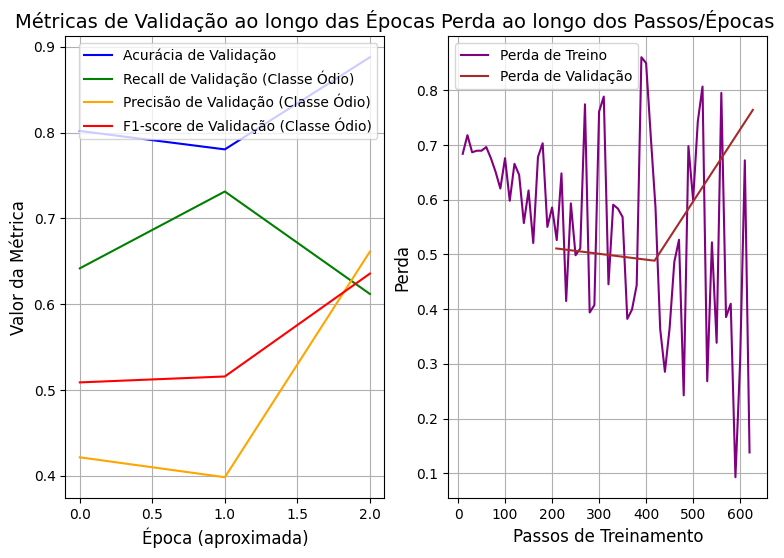

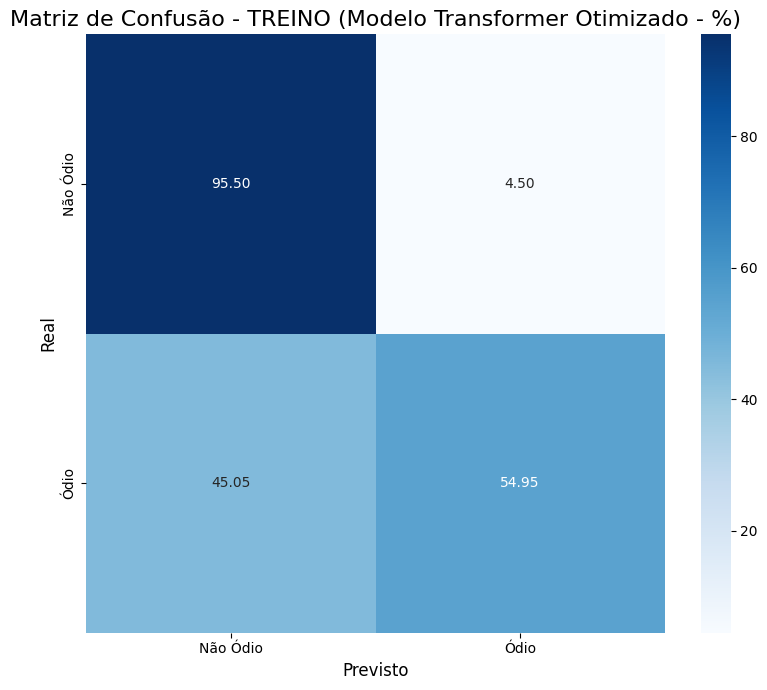


Gráficos do histórico de treinamento e validação gerados.

--- Avaliação do Modelo Transformer Otimizado no Conjunto de TESTE ---


Acurácia (Teste - Modelo Transformer Otimizado): 0.8878
Recall da Classe 'Ódio' (Teste - Modelo Transformer Otimizado): 0.6119
Precisão da Classe 'Ódio' (Teste - Modelo Transformer Otimizado): 0.6613
F1-score da Classe 'Ódio' (Teste - Modelo Transformer Otimizado): 0.6357

Relatório de Classificação (Teste - Modelo Transformer Otimizado):
              precision    recall  f1-score   support

    Não Ódio       0.93      0.94      0.93       352
        Ódio       0.66      0.61      0.64        67

    accuracy                           0.89       419
   macro avg       0.79      0.78      0.78       419
weighted avg       0.88      0.89      0.89       419


Matriz de Confusão (Teste - Modelo Transformer Otimizado - Percentual):


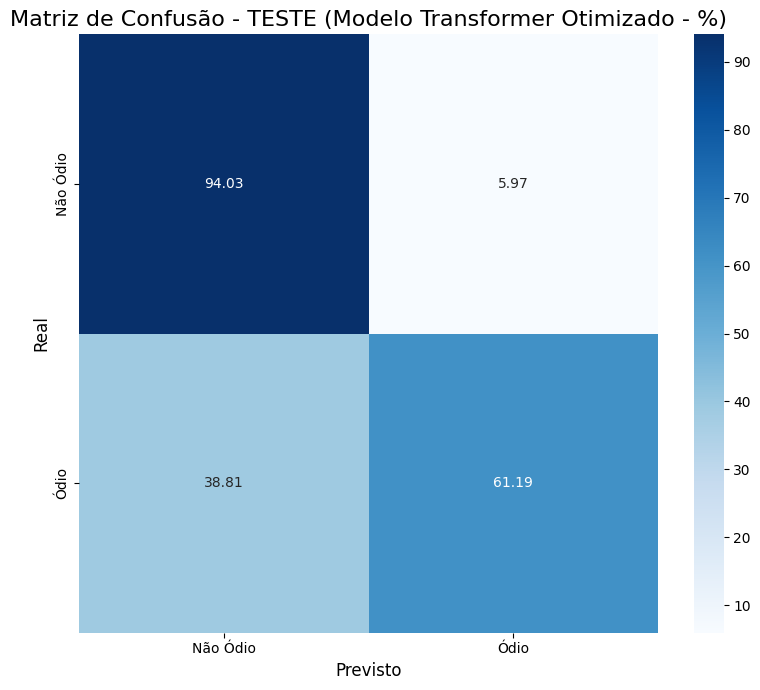


Análise do modelo Transformer com fine-tuning concluída.

Observação: O balanceamento foi realizado via pesos de classe na função de perda. Para um dataset desbalanceado real, esta é uma abordagem recomendada.

**Conclusão:** O modelo agora é otimizado para o recall da classe 'Ódio', o que é crucial para detecção de discurso de ódio. Os gráficos de aprendizado ajudarão a diagnosticar overfitting e a ajustar hiperparâmetros ainda mais.


In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, f1_score, precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers.trainer_utils import IntervalStrategy
from sklearn.utils.class_weight import compute_class_weight
from transformers import EarlyStoppingCallback # Importar se for usar EarlyStopping

# --- 1. Preparar o Ambiente ---
print("Verificando e instalando bibliotecas necessárias (transformers, torch)...")
# Certifique-se de que 'transformers' e 'torch' estão instalados.
# pip install transformers torch scikit-learn pandas matplotlib seaborn

# Verificar disponibilidade da GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU disponível: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU não disponível. Usando CPU.")

# --- 2. Carregar e Pré-processar os Datasets de Treino e Teste Separadamente ---
# Carregamento do dataset de treinamento
# Substitua 'train.csv' pelo caminho real do seu arquivo de treino, se diferente
try:
    df_train = pd.read_csv('train.csv')
    print("\nDataFrame de Treino Carregado de 'train.csv'.")
    print(df_train.head())
    print(f"\nContagem de classes no treino original: {Counter(df_train['odio'])}")
except FileNotFoundError:
    print("\nAVISO: 'train.csv' não encontrado.")

    print(f"\nContagem de classes no treino original: {Counter(df_train['odio'])}")


# Carregamento do dataset de teste
# Substitua 'test.csv' pelo caminho real do seu arquivo de teste, se diferente
try:
    df_test = pd.read_csv('test.csv')
    print("\nDataFrame de Teste Carregado de 'test.csv'.")
    print(df_test.head())
    print(f"\nContagem de classes no teste original: {Counter(df_test['odio'])}")
except FileNotFoundError:
    print("\nAVISO: 'test.csv' não encontrado.")
    print(df_test.head())
    print(f"\nContagem de classes no teste original: {Counter(df_test['odio'])}")


# Mapear os rótulos numéricos para nomes descritivos
class_labels_names = {0: 'Não Ódio', 1: 'Ódio'}

# Atribuir os dados de treino e teste originais
X_train = df_train['comment']
y_train = df_train['odio']
X_test = df_test['comment']
y_test = df_test['odio']

print(f"\nNúmero de amostras de treino (original): {len(X_train)}")
print(f"Número de amostras de teste: {len(X_test)}")


# --- 2.5. Balanceamento de Classes com Pesos de Classe na Função de Perda ---
print("\n--- Balanceamento de Classes: Calculando Pesos de Classe ---")

# Calcular os pesos de classe usando compute_class_weight
# 'balanced' ajusta os pesos inversamente proporcionais às frequências da classe
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train), # Use y_train original para calcular os pesos
    y=y_train
)
# Converter para tensor PyTorch e mover para o dispositivo (CPU/GPU)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float).to(device)

print(f"Pesos de classe calculados: {class_weights_array}")
print("\nOBSERVAÇÃO IMPORTANTE SOBRE BALANCEAMENTO PARA TRANSFORMERS:")
print("O uso de pesos de classe na função de perda é uma técnica eficaz para lidar com datasets desbalanceados em modelos Transformer.")


# --- 3. Carregar Tokenizador e Modelo Pré-treinado (BERT Português) ---
# Modelo BERT pré-treinado em português do NeuralMind (baseado em cased)
model_name = "neuralmind/bert-base-portuguese-cased"
num_labels = len(class_labels_names) # Número de classes (2: Não Ódio, Ódio)

print(f"\nCarregando tokenizador e modelo '{model_name}'...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model.to(device) # Mover o modelo para a GPU, se disponível

print("Tokenizador e modelo carregados e movidos para o dispositivo.")

# --- 4. Tokenização dos Dados ---
# Função para tokenizar e formatar os dados para o Transformer
def tokenize_function(texts, labels):
    # Truncation=True: Trunca sequências mais longas que o max_length do modelo
    # Padding=True: Adiciona padding para que todas as sequências tenham o mesmo comprimento
    encodings = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=128)
    encodings['labels'] = labels.tolist()
    return encodings

train_encodings = tokenize_function(X_train, y_train) # Usa X_train e y_train ORIGINAIS
test_encodings = tokenize_function(X_test, y_test)

print(f"Número de sequências tokenizadas de treino: {len(train_encodings['input_ids'])}")
print(f"Número de sequências tokenizadas de teste: {len(test_encodings['input_ids'])}")

# Classe Dataset para o Trainer
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings.input_ids)

train_dataset = CustomDataset(train_encodings)
test_dataset = CustomDataset(test_encodings)

# --- 5. Definir Argumentos de Treinamento e Trainer (e CustomTrainer para pesos de classe) ---
# Ajuste os parâmetros de treinamento conforme necessário
training_args = TrainingArguments(
    output_dir='/tmp/results',       # Alterado para um diretório gravável
    num_train_epochs=3,              # Sugestão: Reduzido para 5 épocas #Faltou rodar com 3 epocas
    learning_rate=5e-5,              # Sugestão: Reduzido para 3e-5 para convergência mais estável
    per_device_train_batch_size=8,   # Tamanho do batch por dispositivo (GPU/CPU)
    per_device_eval_batch_size=8,    # Tamanho do batch de avaliação por dispositivo
    warmup_steps=500,                # Número de passos para aquecimento do learning rate
    weight_decay=0.1,          #0.01     # Peso para regularização L2
    logging_dir='/tmp/logs',         # Alterado para um diretório gravável
    logging_steps=10,                # Frequência de log (em passos)
    eval_strategy=IntervalStrategy.EPOCH,     # Avaliar no final de cada época
    save_strategy=IntervalStrategy.EPOCH,           # Salvar o modelo no final de cada época
    load_best_model_at_end=True,     # Carregar o melhor modelo (baseado na métrica de avaliação) ao final
    metric_for_best_model="eval_precision", #"eval_recall", # Métrica para determinar o "melhor" modelo (focado em recall da classe minoritária) melhorou ao focar na precisao
    greater_is_better=True,          # Um recall maior é melhor
    report_to="none", # Desabilita o reporte para plataformas como wandb, mlflow, etc.
    # Removido 'callbacks' daqui
)

# Definir a função de métricas para o Trainer
# Sugestão de Melhoria: Adicionado recall, precision e f1_score para avaliação completa.
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    acc = accuracy_score(p.label_ids, predictions)
    # Recall para a classe 'Ódio' (rótulo 1)
    rec = recall_score(p.label_ids, predictions, pos_label=1, average='binary', zero_division=0)
    # Precisão para a classe 'Ódio' (rótulo 1)
    prec = precision_score(p.label_ids, predictions, pos_label=1, average='binary', zero_division=0)
    # F1-score para a classe 'Ódio' (rótulo 1)
    f1 = f1_score(p.label_ids, predictions, pos_label=1, average='binary', zero_division=0)
    return {"accuracy": acc, "recall": rec, "precision": prec, "f1": f1}


# CustomTrainer para aplicar os pesos de classe na função de perda
class CustomTrainer(Trainer):
    # CORREÇÃO: Adicionado o argumento 'num_items_in_batch' com um valor padrão
    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Aplicar os pesos de classe na CrossEntropyLoss
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Instanciar o CustomTrainer com o modelo e argumentos, passando callbacks aqui
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset, # Opcional, para ver performance no conjunto de avaliação
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    # Exemplo de EarlyStopping: Adicionado aqui, descomente para usar
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.001)]

)

# --- 6. Fine-tuning do Modelo ---
print("\nIniciando o fine-tuning do modelo Transformer...")
# Capturando o objeto TrainingOutput para acessar o histórico
train_output = trainer.train()
print("Fine-tuning concluído.")

# 7. Visualizar o Histórico de Treinamento
print("\n--- Visualizando o Histórico de Treinamento ---")

# Accessing logs
train_loss_history = [entry['loss'] for entry in trainer.state.log_history if 'loss' in entry]
eval_accuracy_history = [entry['eval_accuracy'] for entry in trainer.state.log_history if 'eval_accuracy' in entry]
eval_recall_history = [entry['eval_recall'] for entry in trainer.state.log_history if 'eval_recall' in entry]
eval_f1_history = [entry['eval_f1'] for entry in trainer.state.log_history if 'eval_f1' in entry]
eval_precision_history = [entry['eval_precision'] for entry in trainer.state.log_history if 'eval_precision' in entry] # Novo: precisão de validação

# Plotting
plt.figure(figsize=(14, 6)) # Aumentei o tamanho da figura

plt.subplot(1, 3, 1) # 1 linha, 3 colunas, primeiro gráfico
plt.plot(eval_accuracy_history, label='Acurácia de Validação', color='blue')
plt.plot(eval_recall_history, label='Recall de Validação (Classe Ódio)', color='green')
plt.plot(eval_precision_history, label='Precisão de Validação (Classe Ódio)', color='orange') # Novo: Precisão
plt.plot(eval_f1_history, label='F1-score de Validação (Classe Ódio)', color='red')
plt.title('Métricas de Validação ao longo das Épocas', fontsize=14)
plt.xlabel('Época (aproximada)', fontsize=12) # Época aproximada, pois logs podem ser por steps
plt.ylabel('Valor da Métrica', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2) # 1 linha, 3 colunas, segundo gráfico (Perda)
train_steps = [entry['step'] for entry in trainer.state.log_history if 'loss' in entry]
train_losses = [entry['loss'] for entry in trainer.state.log_history if 'loss' in entry]

eval_steps = [entry['step'] for entry in trainer.state.log_history if 'eval_loss' in entry]
eval_losses = [entry['eval_loss'] for entry in trainer.state.log_history if 'eval_loss' in entry]

plt.plot(train_steps, train_losses, label='Perda de Treino', color='purple')
if eval_losses: # Plotar perda de validação apenas se houver dados
    plt.plot(eval_steps, eval_losses, label='Perda de Validação', color='brown')

plt.title('Perda ao longo dos Passos/Épocas', fontsize=14)
plt.xlabel('Passos de Treinamento', fontsize=12)
plt.ylabel('Perda', fontsize=12)
plt.legend()
plt.grid(True)

# --- Convertendo a Matriz de Confusão para Percentual ---
# Divide cada linha pelo somatório da linha para obter percentuais por classe real
cm_train_transformer = confusion_matrix(train_labels_ids, train_predictions)
cm_train_transformer_percent = cm_train_transformer.astype('float') / cm_train_transformer.sum(axis=1)[:, np.newaxis]
# Multiplica por 100 para ter percentual e arredonda para duas casas decimais
cm_train_transformer_percent = np.round(cm_train_transformer_percent * 100, 2)

# Cria um DataFrame para a matriz de confusão em percentual
cm_df_train_transformer_percent = pd.DataFrame(cm_train_transformer_percent,
                                               index=class_labels_names.values(),
                                               columns=class_labels_names.values())

# --- Visualizando a Matriz de Confusão (Treino - Percentual) ---
print("\nGerando Matriz de Confusão (Treino - Percentual) para o Modelo Transformer Otimizado...")

plt.figure(figsize=(8, 7)) # Ajustei o figsize para melhor legibilidade
sns.heatmap(cm_df_train_transformer_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # Alterei fmt e cbar
            xticklabels=class_labels_names.values(), yticklabels=class_labels_names.values())
plt.title('Matriz de Confusão - TREINO (Modelo Transformer Otimizado - %)', fontsize=16)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()
print("\nGráficos do histórico de treinamento e validação gerados.")


# --- 8. Avaliar o Modelo Final no Conjunto de Teste ---
print("\n--- Avaliação do Modelo Transformer Otimizado no Conjunto de TESTE ---")
predictions_raw, labels_ids, metrics = trainer.predict(test_dataset)
predictions = np.argmax(predictions_raw, axis=1)

accuracy_final_transformer = accuracy_score(labels_ids, predictions)
recall_odio_final_transformer = recall_score(labels_ids, predictions, pos_label=1, average='binary', zero_division=0)
precision_odio_final_transformer = precision_score(labels_ids, predictions, pos_label=1, average='binary', zero_division=0)
f1_odio_final_transformer = f1_score(labels_ids, predictions, pos_label=1, average='binary', zero_division=0)


print(f"Acurácia (Teste - Modelo Transformer Otimizado): {accuracy_final_transformer:.4f}")
print(f"Recall da Classe 'Ódio' (Teste - Modelo Transformer Otimizado): {recall_odio_final_transformer:.4f}")
print(f"Precisão da Classe 'Ódio' (Teste - Modelo Transformer Otimizado): {precision_odio_final_transformer:.4f}")
print(f"F1-score da Classe 'Ódio' (Teste - Modelo Transformer Otimizado): {f1_odio_final_transformer:.4f}")


print("\nRelatório de Classificação (Teste - Modelo Transformer Otimizado):")
print(classification_report(labels_ids, predictions, target_names=class_labels_names.values()))

# --- Visualizar a Matriz de Confusão para o Teste ---
print("\nMatriz de Confusão (Teste - Modelo Transformer Otimizado - Percentual):")
cm_test_transformer = confusion_matrix(labels_ids, predictions)

# Converter para percentual
# O sum(axis=1)[:, np.newaxis] garante que a divisão seja feita por linha
cm_test_transformer_percent = cm_test_transformer.astype('float') / cm_test_transformer.sum(axis=1)[:, np.newaxis]
# Multiplicar por 100 e arredondar para duas casas decimais para ter percentuais
cm_test_transformer_percent = np.round(cm_test_transformer_percent * 100, 2)

# Criar um DataFrame para a matriz de confusão em percentual (opcional, mas bom para consistência)
cm_df_test_transformer_percent = pd.DataFrame(cm_test_transformer_percent,
                                              index=class_labels_names.values(),
                                              columns=class_labels_names.values())

plt.figure(figsize=(8, 7)) # Aumentei o figsize para melhor legibilidade dos percentuais
sns.heatmap(cm_df_test_transformer_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, # Alterado fmt e cbar
            xticklabels=class_labels_names.values(), yticklabels=class_labels_names.values())
plt.title('Matriz de Confusão - TESTE (Modelo Transformer Otimizado - %)', fontsize=16)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

print("\nAnálise do modelo Transformer com fine-tuning concluída.")
print("\nObservação: O balanceamento foi realizado via pesos de classe na função de perda. Para um dataset desbalanceado real, esta é uma abordagem recomendada.")
print("\n**Conclusão:** O modelo agora é otimizado para o recall da classe 'Ódio', o que é crucial para detecção de discurso de ódio. Os gráficos de aprendizado ajudarão a diagnosticar overfitting e a ajustar hiperparâmetros ainda mais.")

## **Calibração entre os modelos**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
# Ex: Suas variáveis de dados de teste
#X_test = df_test['comment']
#y_test = df_test['odio']

In [ ]:
# Modelos treinados
mnb_clf = model_nb_balanced
rf_default_model = model_rf_balanced_default
rf_grid_model = model_rf_grid_optimized # Corrected variable name
rf_random_model = model_rf_random_optimized # Corrected variable name
gb_optimized_model = model_gb_optimized


Probabilidades do Transformer obtidas com sucesso.


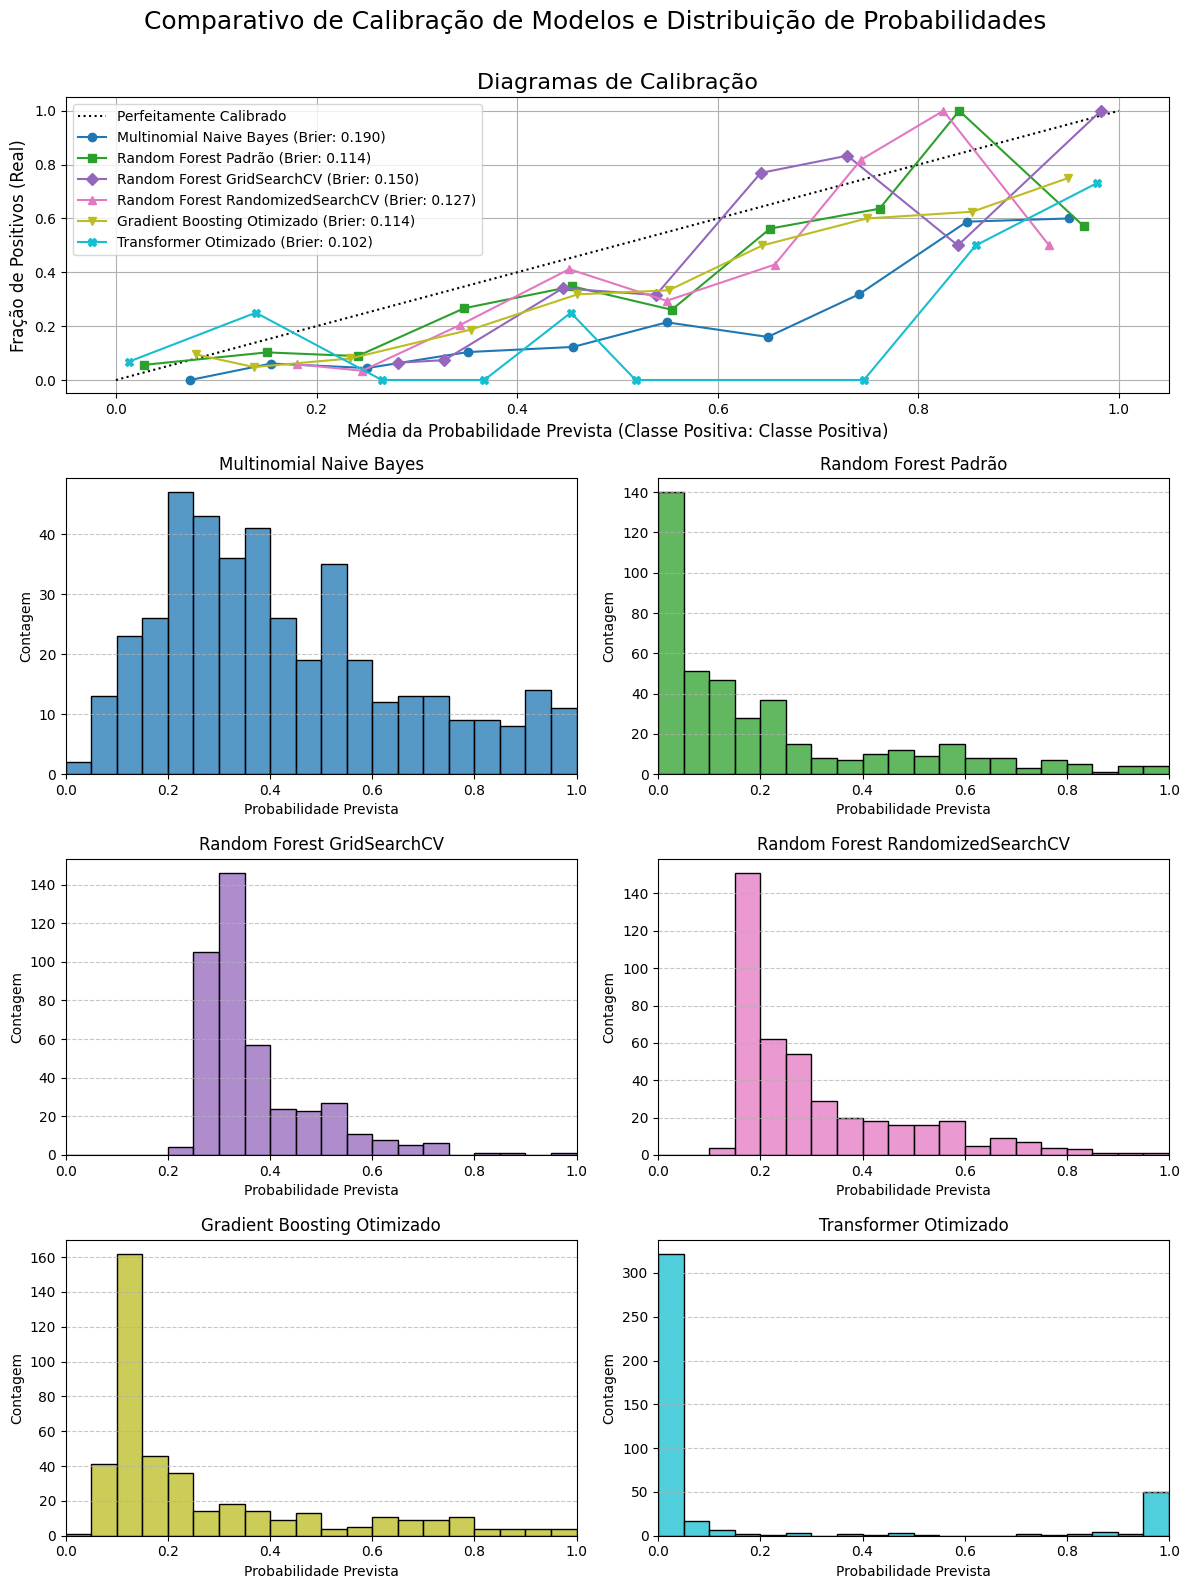


Comparativo de calibração gerado com sucesso com os dados do seu projeto!


In [ ]:
# Obter probabilidades do modelo Transformer
try:
    predictions_raw_transformer, _, _ = trainer.predict(test_dataset)
    probs_transformer_test = torch.softmax(torch.tensor(predictions_raw_transformer), dim=1).numpy()
    print("\nProbabilidades do Transformer obtidas com sucesso.")
except NameError:
    print("\nAviso: Variáveis 'trainer' ou 'test_dataset' não encontradas. Não é possível obter probabilidades do Transformer.")
    probs_transformer_test = None # Define as None if not available
except Exception as e:
    print(f"\nErro ao obter probabilidades do Transformer: {e}")
    probs_transformer_test = None

model_probs = {}

try:
    # Use X_test_vectorized for MNB
    model_probs['Multinomial Naive Bayes'] = mnb_clf.predict_proba(X_test_vectorized)[:, 1]
except NameError:
    print("Variável 'mnb_clf' não encontrada. Ignorando Multinomial Naive Bayes.")
except Exception as e:
    print(f"Erro ao obter probabilidades de Multinomial Naive Bayes: {e}")

try:
    # Use X_test_vectorized for Random Forest
    model_probs['Random Forest Padrão'] = rf_default_model.predict_proba(X_test_vectorized)[:, 1]
except NameError:
    print("Variável 'rf_default_model' não encontrada. Ignorando Random Forest Padrão.")

try:
    # Use X_test_vectorized for Random Forest GridSearchCV
    model_probs['Random Forest GridSearchCV'] = rf_grid_model.predict_proba(X_test_vectorized)[:, 1]
except NameError:
    print("Variável 'rf_grid_model' não encontrada. Ignorando Random Forest GridSearchCV.")

try:
    # Use X_test_vectorized for Random Forest RandomizedSearchCV
    model_probs['Random Forest RandomizedSearchCV'] = rf_random_model.predict_proba(X_test_vectorized)[:, 1]
except NameError:
    print("Variável 'rf_random_model' não encontrada. Ignorando Random Forest RandomizedSearchCV.")

try:
    # Use X_test_vectorized for Gradient Boosting
    model_probs['Gradient Boosting Otimizado'] = gb_optimized_model.predict_proba(X_test_vectorized)[:, 1]
except NameError:
    print("Variável 'gb_optimized_model' não encontrada. Ignorando Gradient Boosting Otimizado.")

if probs_transformer_test is not None:
    model_probs['Transformer Otimizado'] = probs_transformer_test[:, 1]


# --- 2. Definir o layout dos subplots dinamicamente ---
num_models = len(model_probs)
if num_models == 0:
    print("Nenhum modelo válido encontrado para plotagem. Verifique suas variáveis.")
    # exit() # Removed exit() to allow the cell to finish cleanly
else:
    num_cols_hist = 2 # Dois histogramas por linha
    num_rows_hist = (num_models + num_cols_hist - 1) // num_cols_hist
    total_rows = 1 + num_rows_hist # 1 para o gráfico de calibração + linhas para histogramas

    fig = plt.figure(figsize=(num_cols_hist * 6, total_rows * 4)) # Ajuste o tamanho da figura

    gs = plt.GridSpec(total_rows, num_cols_hist, figure=fig)

    # --- 3. Plotar o Diagrama de Calibração (Top Plot) ---
    ax_calibration = fig.add_subplot(gs[0, :]) # Ocupa todas as colunas da primeira linha

    ax_calibration.plot([0, 1], [0, 1], "k:", label="Perfeitamente Calibrado", linestyle='dotted')

    # Cores e marcadores para cada modelo
    # Garante que temos cores e marcadores suficientes
    colors = plt.cm.get_cmap('tab10', num_models).colors # Ou use uma lista fixa como plt.cm.Dark2.colors + plt.cm.Set1.colors
    markers = ['o', 's', 'D', '^', 'v', 'X', 'P', '*', '<', '>'] # Mais marcadores

    # Assuming class_labels_names is defined earlier in the notebook
    positive_class_name = class_labels_names.get(1, "1") if 'class_labels_names' in globals() else "1"

    for i, (model_name, probs) in enumerate(model_probs.items()):
        # Calcula a curva de calibração
        fraction_of_positives, mean_predicted_value = calibration_curve(y_test, probs, n_bins=10)
        brier = brier_score_loss(y_test, probs)

        # Plotar a curva
        ax_calibration.plot(mean_predicted_value, fraction_of_positives,
                            marker=markers[i % len(markers)],
                            color=colors[i % len(colors)],
                            label=f"{model_name} (Brier: {brier:.3f})")

    ax_calibration.set_title('Diagramas de Calibração', fontsize=16)
    ax_calibration.set_xlabel(f'Média da Probabilidade Prevista (Classe Positiva: {positive_class_name})', fontsize=12)
    ax_calibration.set_ylabel('Fração de Positivos (Real)', fontsize=12)
    ax_calibration.legend(loc="upper left", fontsize=10)
    ax_calibration.grid(True)


    # --- 4. Plotar os Histogramas de Probabilidade (Plots Inferiores) ---
    for i, (model_name, probs) in enumerate(model_probs.items()):
        row_idx = 1 + (i // num_cols_hist)
        col_idx = i % num_cols_hist
        ax_hist = fig.add_subplot(gs[row_idx, col_idx])

        sns.histplot(probs, bins=np.linspace(0, 1, 21), kde=False,
                     color=colors[i % len(colors)], ax=ax_hist)
        ax_hist.set_title(f'{model_name}', fontsize=12)
        ax_hist.set_xlabel('Probabilidade Prevista', fontsize=10)
        ax_hist.set_ylabel('Contagem', fontsize=10)
        ax_hist.set_xlim(0, 1)
        ax_hist.grid(axis='y', linestyle='--', alpha=0.7)


    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta o layout, deixando espaço para o título geral
    plt.suptitle('Comparativo de Calibração de Modelos e Distribuição de Probabilidades', fontsize=18, y=0.99)
    plt.show()

    print("\nComparativo de calibração gerado com sucesso com os dados do seu projeto!")